# Cosmological Constraints: SNIa + BAO + CMB + CC

## Overview

This notebook constrains four cosmological models using late-universe
observational data and compares them via Bayesian evidence.

**Models:** $\Lambda$CDM, $w$CDM, CPL ($w_0 w_a$CDM), $\Lambda_s$CDM
(sign-switching cosmological constant; Akarsu et al. 2023).

**Datasets:**
- **SnIa**: Pantheon+ (1701 SNe) and/or DES-Dovekie (verify sample size on load)
- **BAO**: DESI DR2 (isotropic + anisotropic, including Ly$\alpha$ at $z=2.33$)
- **CMB**: Planck 2018 compressed ($R$, $\ell_a$, $\omega_b$)
- **CC**: Cosmic chronometers $H(z)$
- **SH0ES geometric calibration**: the 77 Cepheid-host SNe of Pantheon+,
  used as a computed $M_B$ anchor (see §2d cont. and the dual-fit note in §3).

**Two SNIa treatments (shown side by side for every model):**
1. **Uncalibrated** — $M_B$ is a free parameter; $H_0$ is therefore determined
   by CMB+BAO (inverse distance ladder). This is the baseline.
2. **SH0ES-anchored** — the geometric Cepheid $M_B$ enters as a prior
   (`chi2_calibrators`). Comparing the two isolates the effect of the local
   distance-ladder information; Appendix A.3 verifies the anchor reproduces
   the SH0ES $H_0$/$M_B$ when CMB+BAO are removed.

**Sampler:** Nautilus (importance nested sampling) + scipy Nelder-Mead
for profile likelihoods.

**Structure:**
1. **§1 Setup** and **§2 Data** — must run sequentially first.
2. **§3–§6** — one section per model. Each has a Pantheon+ fit, a
   SH0ES-anchored Pantheon+ fit, and a DES-Dovekie fit. §6 (Λ$_s$CDM)
   also carries the model-specific diagnostics (§6.3 profile, §6.4 BAO grid).
3. **§7** overlays all models; **§8** computes the Bayesian evidence.
4. The Λ$_s$CDM section (§6) and the multi-seed evidence (§8) are the
   most expensive.

**Outputs:** all corner plots, comparison figures, and diagnostic
plots are saved as PDF to the working directory.


In [34]:
!pip install -U nautilus-sampler getdist

---
# 1. Setup

Constants, fiducial parameters, core cosmological functions
(including the Aizpuru $r_d$ fit), the SH0ES $H_0$ prior, and the
results-table helper.


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from nautilus import Prior, Sampler
from getdist import MCSamples, plots
import urllib.request
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')


## 1.1 Constants & fiducial parameters


In [36]:
# Fundamental constants
c = 299792.458        # Speed of light [km/s]
Tcmb = 2.7255         # CMB temperature today [K]
cH0 = 2997.92458      # Hubble distance c/(100 km/s/Mpc)

# Planck 2018 fiducial values
obh2pl = 0.02236      # Omega_b h^2
ompl   = 0.3166       # Omega_m
H0pl   = 67.27        # H_0 [km/s/Mpc]
h0pl   = H0pl / 100.0

## 1.2 Core cosmological functions


In [37]:
# ================================================================
# VECTORIZED E(z) — works with scalar or array z
# ================================================================

def E2(z, om, h, w0, wa):
    z = np.asarray(z, dtype=float)
    a = 1.0 / (1.0 + z)
    
    # Radiation: physical density Ω_r h² = 4.18e-5 (Planck 2018, Tcmb=2.7255K)
    om_r = 4.18e-5 / h**2
    om_de = 1.0 - om - om_r
    rde = a**(-3.0*(1.0 + w0 + wa)) * np.exp(-3.0*wa*(1.0 - a))
    
    return om * a**(-3) + om_r * a**(-4) + om_de * rde

def E(z, om, h, w0, wa):
    return np.sqrt(E2(z, om, h, w0, wa))

def H_z(z, om, h, w0, wa):
    return 100.0 * h * E(z, om, h, w0, wa)

# ================================================================
# FAST VECTORIZED D_L — cumulative trapezoid (for SNIa)
# ================================================================
N_GRID = 1500

def DL_array(z_arr, om, h, w0, wa):
    z_arr = np.asarray(z_arr)
    z_max = z_arr.max() + 0.05
    z_grid = np.concatenate([
        [0.0],
        np.logspace(np.log10(1e-4), np.log10(z_max), N_GRID - 1)
    ])

    inv_E = 1.0 / E(z_grid, om, h, w0, wa)
    chi_grid = np.concatenate([[0.0], np.cumsum(
        0.5 * (inv_E[:-1] + inv_E[1:]) * np.diff(z_grid)
    )])
    chi = np.interp(z_arr, z_grid, chi_grid)
    return (cH0 / h) * (1.0 + z_arr) * chi 

# ================================================================
# SCALAR DISTANCES — for BAO/CMB (few evals, need quad precision)
# ================================================================

def D_L(z, om, h, w0, wa):
    result, _ = quad(lambda zp: 1.0 / E(zp, om, h, w0, wa), 0.0, z)
    return (1.0 + z) * result

def D_M(z, om, h, w0, wa):
    result, _ = quad(lambda zp: 1.0 / E(zp, om, h, w0, wa), 0.0, z)
    return (cH0 / h) * result

def D_H(z, om, h, w0, wa):
    return c / H_z(z, om, h, w0, wa)

def D_V(z, om, h, w0, wa):
    dm = D_M(z, om, h, w0, wa)
    dh = D_H(z, om, h, w0, wa)
    return (z * dm**2 * dh)**(1.0 / 3.0)

def d_A(z, om, h, w0, wa):
    return D_M(z, om, h, w0, wa) / (1.0 + z)

# ================================================================
# BARYON PHYSICS & SOUND HORIZON
# ================================================================

def R_baryon(z, obh2):
    return 31500.0 * obh2 * (Tcmb / 2.7)**(-4) / (1.0 + z)

def c_s(z, obh2):
    return c / np.sqrt(3.0 * (1.0 + R_baryon(z, obh2)))

def z_cmb(om, obh2, h):
    om_h2 = om * h**2
    g1 = (0.0783 * obh2**(-0.238)) / (1.0 + 39.5 * obh2**0.763)
    g2 = 0.560 / (1.0 + 21.1 * obh2**1.81)
    return 1048.0 * (1.0 + 0.00124 * obh2**(-0.738)) * (1.0 + g1 * om_h2**g2)

def z_drag(om, obh2, h):
    om_h2 = om * h**2
    b1 = 0.313 * om_h2**(-0.419) * (1.0 + 0.607 * om_h2**0.674)
    b2 = 0.238 * om_h2**0.223
    return 1291.0 * om_h2**0.251 / (1.0 + 0.659 * om_h2**0.828) * (1.0 + b1 * obh2**b2)

def rd_GA(om, h, obh2):
    omh2 = om * h**2
    return 1.0 / (
        0.00785436 * obh2**0.177084 +
        0.00912388 * omh2**0.618711 +
        11.9611   * obh2**2.81343  * omh2**0.784719
    )


def r_s(ze_func, om, obh2, h, w0, wa):
    z_epoch = ze_func(om, obh2, h)
    result, _ = quad(lambda z: c_s(z, obh2) / H_z(z, om, h, w0, wa), z_epoch, np.inf)
    return result

def R_shift(om, obh2, h, w0, wa):
    z_star = z_cmb(om, obh2, h)
    return np.sqrt(om * (100*h)**2) * D_M(z_star, om, h, w0, wa) / c

def l_a(om, obh2, h, w0, wa):
    z_star = z_cmb(om, obh2, h)
    return np.pi * D_M(z_star, om, h, w0, wa) / r_s(z_cmb, om, obh2, h, w0, wa)

### r_d via Aizpuru GA fit

The original BAO χ² used the integral approach `r_s(z_drag, ...)` with the EH98 fitting formula for z_drag. This combination introduces a **~2.4% systematic bias** in r_d compared to CAMB (verified: 150.6 Mpc vs 147.05 Mpc at Planck best-fit), which cascades into ~10 ln Z spurious shifts in Λ_sCDM Bayesian evidence.

The fix replaces r_d in **BAO χ² only** with the Aizpuru-Arjona-Nesseris (2021) GA fit:

$$\frac{1}{r_d} = a_1 \, \omega_b^{a_2} + a_3 \, \omega_m^{a_4} + a_5 \, \omega_b^{a_6} \, \omega_m^{a_7}$$

which is calibrated against CAMB to ~0.003% accuracy.

The CMB compressed likelihood (R, l_a, ω_b) still uses `r_s(z_cmb, ...)` integral — this is verified accurate (~0.2% bias) because Hu-Sugiyama z_cmb formula is precise.

## 1.3 SH0ES $H_0$ prior


In [39]:
# --- SH0ES (Riess et al. 2022): H0 = 73.04 ± 1.04 ---
def chi2_H0_shoes(h):
    return ((h - 0.7304) / 0.0104)**2

print('H₀ prior defined: chi2_H0_shoes(h)')

H₀ prior defined: chi2_H0_shoes(h)


## 1.4 Helper: results table


In [40]:
def print_results(title, points, weights, names, labels):
    w = weights.copy()
    w /= w.sum()
    print(f'\n{"═" * 58}')
    print(f'  {title}')
    print(f'{"═" * 58}')
    print(f'{"Parameter":>20s} {"Median":>10s} {"+1σ":>9s} {"-1σ":>9s}')
    print(f'{"─" * 58}')
    res = {}
    for i, (n, l) in enumerate(zip(names, labels)):
        idx = np.argsort(points[:, i])
        cw = np.cumsum(w[idx])
        p16 = points[idx[np.searchsorted(cw, 0.16)], i]
        p50 = points[idx[np.searchsorted(cw, 0.50)], i]
        p84 = points[idx[np.searchsorted(cw, 0.84)], i]
        print(f'{l:>20s} {p50:10.4f} {p84-p50:+9.4f} {p16-p50:+9.4f}')
        res[n] = (p50, p84-p50, p50-p16)
    print(f'{"─" * 58}')
    return res

---
# 2. Data


## 2a. Planck 2018 CMB (compressed)


In [41]:
data_cmb = np.array([1.74963, 301.80845, 0.02237])
n_cmb = len(data_cmb)

cov_cmb = 1e-8 * np.array([
    [ 1598.9554,   17112.007,    -36.311179],
    [ 17112.007,   811208.45,   -494.79813 ],
    [ -36.311179, -494.79813,      2.1242182]
])
invcov_cmb = np.linalg.inv(cov_cmb)

def chi2_cmb(om, obh2, h, w0, wa):
    theory = np.array([R_shift(om, obh2, h, w0, wa),
                       l_a(om, obh2, h, w0, wa), obh2])
    v = theory - data_cmb
    return v @ invcov_cmb @ v

print(f'CMB: {n_cmb} observables (R, l_a, Ω_b h²)')

CMB: 3 observables (R, l_a, Ω_b h²)


## 2b. DESI DR2 BAO


In [42]:
# ================================================================
# DESI DR2 BAO — arXiv:2503.14738, Table IV
# ================================================================

# --- Isotropic bin: DV/rd only ---
# BGS is still isotropic in DR2 (monopole-only fit)
# Verify from published Table IV or cobaya bao_data/desi_dr2
desi_iso = [
    (0.295,  7.942, 0.075),   # BGS
]

# --- Anisotropic bins: DM/rd, DH/rd with correlation r_M,H ---
# Note: QSO upgraded from isotropic (DR1) to anisotropic (DR2)
# Lyα errors are stat+sys combined in quadrature
desi_aniso = [
    (0.510, 13.587, 0.169, 21.863, 0.427, -0.475),  # LRG1
    (0.706, 17.347, 0.180, 19.458, 0.332, -0.423),  # LRG2
    (0.934, 21.574, 0.153, 17.641, 0.193, -0.425),  # LRG3+ELG1
    (1.321, 27.605, 0.320, 14.178, 0.217, -0.437),  # ELG2
    (1.484, 30.519, 0.758, 12.816, 0.513, -0.489),  # QSO (now anisotropic)
    (2.330, 38.988, 0.531,  8.632, 0.101, -0.431),  # Lyα (stat+sys)
]
n_bao = len(desi_iso) + 2 * len(desi_aniso)

def chi2_bao_desi(om, obh2, h, w0, wa):
    rd = rd_GA(om, h, obh2)
    chi2 = 0.0
    for z_eff, dv_obs, sigma in desi_iso:
        chi2 += ((dv_obs - D_V(z_eff, om, h, w0, wa) / rd) / sigma)**2
    for z_eff, dm_obs, sig_dm, dh_obs, sig_dh, r_corr in desi_aniso:
        dm_th = D_M(z_eff, om, h, w0, wa) / rd
        dh_th = D_H(z_eff, om, h, w0, wa) / rd
        cov = np.array([[sig_dm**2, r_corr*sig_dm*sig_dh],
                        [r_corr*sig_dm*sig_dh, sig_dh**2]])
        delta = np.array([dm_obs - dm_th, dh_obs - dh_th])
        chi2 += delta @ np.linalg.inv(cov) @ delta
    return chi2

print(f'DESI DR2 BAO: {n_bao} data points in 7 bins')
print(f'  χ²_BAO(Planck fid.) = {chi2_bao_desi(ompl, obh2pl, h0pl, -1, 0):.2f}')

DESI DR2 BAO: 13 data points in 7 bins
  χ²_BAO(Planck fid.) = 39.06


## 2c. Cosmic Chronometers $H(z)$
33 points, block-diagonal covariance
• 18 uncorrelated: Moresco (2024), arXiv:2412.01994, Table 1 (excluding 2 of 3 'a'-flagged duplicates per Pataki+ 2025, A&A)
• 15 correlated:  Moresco et al. (2012, 2015, 2016) BC03 measurements with full 15×15 syst+stat covariance from Moresco+ 2020 (https://gitlab.com/mmoresco/CCcovariance)

In [43]:
cc_hz_file  = 'HzTable_MM_BC03.dat'
cc_cov_file = 'CovMat_CC_BC03_Hz_15.dat'
cc_unc_file = 'cc_uncorrelated_18pts.csv'
cc_base = 'https://gitlab.com/mmoresco/CCcovariance/-/raw/master/data/'

# Download Moresco-group files if missing
for f in [cc_hz_file, cc_cov_file]:
    if not os.path.exists(f):
        try:
            print(f'Downloading {f}...')
            urllib.request.urlretrieve(cc_base + f, f)
        except Exception as e:
            print(f'⚠ {f} download failed: {e}')

try:
    #1 15 correlated Moresco-group points (preserve file order!)
    cc_corr = pd.read_csv(cc_hz_file, comment='#', header=None, sep=',',
                          usecols=[0, 1, 2], names=['z', 'Hz', 'errHz'])
    z_corr   = cc_corr['z'].values.astype(float)
    H_corr   = cc_corr['Hz'].values.astype(float)
    sig_corr = cc_corr['errHz'].values.astype(float)
    cov15    = np.loadtxt(cc_cov_file)

    assert len(z_corr) == 15, f'Expected 15 correlated points, got {len(z_corr)}'
    assert cov15.shape == (15, 15), f'Expected 15×15 covariance, got {cov15.shape}'

    #2 18 uncorrelated points (Moresco 2024 Table 1, filtered)
    cc_unc = pd.read_csv(cc_unc_file, comment='#')
    z_unc   = cc_unc['z'].values.astype(float)
    H_unc   = cc_unc['Hz'].values.astype(float)
    sig_unc = cc_unc['errHz'].values.astype(float)
    assert len(z_unc) == 18, f'Expected 18 uncorrelated points, got {len(z_unc)}'

    #3 Concatenate: [18 uncorrelated; 15 correlated]
    z_cc   = np.concatenate([z_unc, z_corr])
    H_cc   = np.concatenate([H_unc, H_corr])
    sig_cc = np.concatenate([sig_unc, sig_corr])
    n_cc   = len(z_cc)

    #4 Block-diagonal covariance: diag(σ²) ⊕ cov15
    CovCC = np.diag(sig_cc**2)
    CovCC[18:, 18:] = cov15
    InvCovCC = np.linalg.inv(CovCC)

    # --- Sanity prints ---
    print(f'Cosmic Chronometers: {n_cc} H(z) points (18 uncorr + 15 corr)')
    print(f'  z ∈ [{z_cc.min():.3f}, {z_cc.max():.3f}]')
    print(f'  Cov shape: {CovCC.shape},  cond(Cov) = {np.linalg.cond(CovCC):.2e}')
    print(f'  References in uncorrelated block:')
    for ref, n in cc_unc["ref"].value_counts().items():
        print(f'    • {ref}: {n}')

    CC_LOADED = True
except Exception as e:
    print(f'⚠ Cosmic Chronometers not loaded: {e}')
    CC_LOADED = False


def chi2_cc(om, h, w0=-1.0, wa=0.0):
    H_th  = 100.0 * h * E(z_cc, om, h, w0, wa)
    delta = H_cc - H_th
    return delta @ InvCovCC @ delta

Cosmic Chronometers: 33 H(z) points (18 uncorr + 15 corr)
  z ∈ [0.070, 1.965]
  Cov shape: (33, 33),  cond(Cov) = 2.45e+02
  References in uncorrelated block:
    • Simon2005: 9
    • Zhang2014: 4
    • Stern2010: 2
    • Ratsimbazafy2017: 1
    • Borghi2022: 1
    • Tomasetti2023: 1


## 2d. Pantheon+ SnIa


In [44]:
base_url = ('https://raw.githubusercontent.com/PantheonPlusSH0ES/'
            'DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/')
data_file = 'Pantheon+SH0ES.dat'
cov_file  = 'Pantheon+SH0ES_STAT+SYS.cov'

if not os.path.exists(data_file):
    print('Downloading Pantheon+ catalog...')
    urllib.request.urlretrieve(base_url + 'Pantheon%2BSH0ES.dat', data_file)
if not os.path.exists(cov_file):
    print('Downloading Pantheon+ covariance...')
    urllib.request.urlretrieve(
        base_url + 'Pantheon%2BSH0ES_STAT%2BSYS.cov', cov_file)

#1 LOAD ───────────────────────────────────────────────────────
df_pp = pd.read_csv(data_file, sep=r'\s+')
n_sne = len(df_pp)

with open(cov_file) as f:
    lines = f.readlines()
n_cov = int(lines[0].strip())
CovTotal = np.array([float(v) for l in lines[1:] for v in l.split()]).reshape(n_sne, n_sne)

#2 FILTER CALIBRATORS ─────────────────────────────────────────
mask = df_pp['IS_CALIBRATOR'] == 0
idx  = np.where(mask)[0]

z_HD    = df_pp.loc[mask, 'zHD'].values.astype(float)
z_hel   = df_pp.loc[mask, 'zHEL'].values.astype(float)
mb_corr = df_pp.loc[mask, 'm_b_corr'].values.astype(float)
z_hel_corr = (1.0 + z_hel) / (1.0 + z_HD)

CovCos      = CovTotal[np.ix_(idx, idx)]
InvCovTotal = np.linalg.inv(CovCos)

print(f'Pantheon+: {n_sne} SNe Ia total, {mask.sum()} for cosmology, '
      f'z ∈ [{z_HD.min():.4f}, {z_HD.max():.4f}]')

#3 CHI2 ───────────────────────────────────────────────────────
def chi2_snia_physical(M_abs, om, h, w0=-1.0, wa=0.0):
    DL    = z_hel_corr * DL_array(z_HD, om, h, w0, wa)
    delta = mb_corr - (M_abs + 5.0*np.log10(DL) + 25.0)
    return delta @ InvCovTotal @ delta

Pantheon+: 1701 SNe Ia total, 1624 for cosmology, z ∈ [0.0030, 2.2614]


### 2d (cont.) — Geometric Cepheid calibrators (computed $M_B$)

`chi2_calibrators(M_abs)` = the geometric $M_B$ from the 77 Cepheid-host SNe
($-19.249\pm0.030$), used as the prior in the §X.1 anchored fits. Additive;
baselines untouched. (Pantheon+ only, DES is a distance-modulus product and is
left as it is)

In [45]:
cal_mask  = df_pp['IS_CALIBRATOR'] == 1
cal_idx   = np.where(cal_mask)[0]
mb_cal    = df_pp.loc[cal_mask, 'm_b_corr'].values.astype(float)
mu_ceph   = df_pp.loc[cal_mask, 'CEPH_DIST'].values.astype(float)
InvCovCal = np.linalg.inv(CovTotal[np.ix_(cal_idx, cal_idx)])
print(f'Calibrators: {cal_mask.sum()} SNe in {len(np.unique(np.round(mu_ceph,4)))} Cepheid hosts')

def chi2_calibrators(M_abs):
    delta = mb_cal - (M_abs + mu_ceph)
    return delta @ InvCovCal @ delta

Calibrators: 77 SNe in 37 Cepheid hosts


## 2e. DES-Dovekie SnIa


In [46]:
des_base = ('https://raw.githubusercontent.com/des-science/'
            'DES-SN5YR/main/4_DISTANCES_COVMAT/')

if not os.path.exists('DES-Dovekie_HD.csv'):
    try:
        print('Downloading DES-Dovekie_HD.csv...')
        urllib.request.urlretrieve(des_base + 'DES-Dovekie_HD.csv',
                                  'DES-Dovekie_HD.csv')
    except Exception as e:
        print(f'⚠ Download failed: {e}')
        print('  → Download manually from: https://github.com/des-science/DES-SN5YR')

if not os.path.exists('STAT+SYS.npz'):
    try:
        print('Downloading STAT+SYS.npz...')
        npz_url = ('https://github.com/des-science/DES-SN5YR/'
                   'raw/main/4_DISTANCES_COVMAT/STAT+SYS.npz')
        urllib.request.urlretrieve(npz_url, 'STAT+SYS.npz')
    except Exception as e:
        print(f'⚠ Download failed: {e}')
        print('  → Download manually from: https://github.com/des-science/DES-SN5YR')

try:
    # --- Parse DES data ---
    df_des = pd.read_csv('DES-Dovekie_HD.csv',
                         comment='#',
                         sep=r'\s+',
                         header=None)
    varnames_row = df_des[df_des[0] == 'VARNAMES:'].index[0]
    col_names = ['type'] + df_des.iloc[varnames_row, 1:].tolist()
    df_des = df_des[df_des[0] == 'SN:'].reset_index(drop=True)
    df_des.columns = col_names[:len(df_des.columns)]

    z_cmb_des  = df_des['zHD'].values.astype(float)
    z_hel_des  = df_des['zHEL'].values.astype(float)
    mu_obs_des = df_des['MU'].values.astype(float)
    n_des      = len(z_cmb_des)

    # --- Parse INVERSE covariance (upper triangular format) ---
    # The STAT+SYS.npz file contains the INVERSE covariance (precision matrix)
    cov_data = np.load('STAT+SYS.npz', allow_pickle=True)
    n_cov    = int(cov_data['nsn'][0])  # 1820

    InvCovDES = np.zeros((n_cov, n_cov), dtype=np.float64)
    InvCovDES[np.triu_indices(n_cov)] = cov_data['cov']
    i_lower = np.tril_indices(n_cov, -1)
    InvCovDES[i_lower] = InvCovDES.T[i_lower]
    # Used directly — no inversion needed

    print(f'DES-Dovekie: {n_des} SNe Ia, '
          f'z ∈ [{z_cmb_des.min():.3f}, {z_cmb_des.max():.3f}]')
    print(f'InvCovDES diag mean:  {np.diag(InvCovDES).mean():.4f}')
    DES_LOADED = True

except Exception as e:
    print(f'⚠ DES-Dovekie not loaded: {e}')
    print('  Download DES-Dovekie_HD.csv and STAT+SYS.npz from:')
    print('  https://github.com/des-science/DES-SN5YR')
    DES_LOADED = False


def chi2_des(om, h, w0=-1.0, wa=0.0):
    """DES-Dovekie chi2 with analytical marginalization over M (astro-ph/0104009, Eq. A9-12)"""
    DL    = DL_array(z_cmb_des, om, h, w0, wa)
    mu_th = 5*np.log10((1+z_hel_des)/(1+z_cmb_des) * DL) + 25.0

    delta = mu_th - mu_obs_des

    chit2 = delta @ InvCovDES @ delta
    B     = np.sum(InvCovDES @ delta)
    C_sum = np.sum(InvCovDES)
    return chit2 - (B**2 / C_sum) + np.log(C_sum / (2*np.pi))

DES-Dovekie: 1820 SNe Ia, z ∈ [0.025, 1.144]
InvCovDES diag mean:  42.8061


### A note on the two SNIa treatments (applies to §3–§6)

Each model below is fit twice on the Pantheon+ data:

- **Baseline (uncalibrated):** $M_B$ free, so the supernova absolute scale is
  marginalised and $H_0$ comes from CMB+BAO. This avoids importing the SH0ES
  calibration and keeps the analysis an inverse distance ladder.
- **SH0ES-anchored:** the same fit plus `chi2_calibrators`, the geometric $M_B$
  constraint from the 77 Cepheid-host SNe. The fit reparametrises through
  $\mathcal{M} \equiv M_B + 5\log_{10}(c/H_0) + 25$ so the anchor enters cleanly.

Reading the two together is the point: if the local ($H_0\simeq73$) and early
($H_0\simeq68$) information were consistent, the anchored fit would simply tighten
$H_0$. Instead it stays near the CMB+BAO value (~68.9) because that combined
constraint outweighs the $M_B$ prior — i.e. the $H_0$ tension is visible *inside*
the fit, not resolved by it. Appendix A.3 confirms the anchor is correctly
implemented by recovering $H_0\simeq73.4$, $M_B\simeq-19.25$ when CMB+BAO are dropped.

The DES-Dovekie fits are left uncalibrated throughout (DES provides a
distance-modulus product, not raw $m_B$ with Cepheid hosts).


---
# 3. $\Lambda$CDM


## 3.1 Pantheon+


Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 49700    | N/A    | 11030 | -762.66  

══════════════════════════════════════════════════════════
  ΛCDM — SNIa + BAO + CMB + CC
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                 Ω_m     0.3026   +0.0036   -0.0035
                   h     0.6854   +0.0028   -0.0028
                 ω_b     0.0225   +0.0001   -0.0001
               M_cal    23.7961   +0.0037   -0.0039
──────────────────────────────────────────────────────────
Removed no burn in


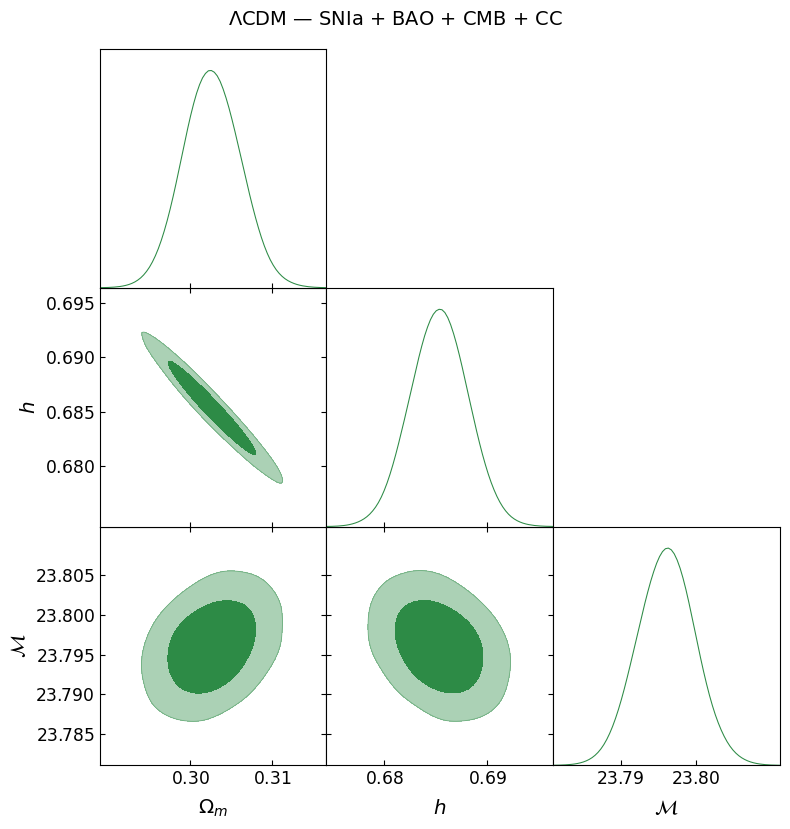

In [47]:
prior_lcdm = Prior()
prior_lcdm.add_parameter('om',   dist=(0.1, 0.5))
prior_lcdm.add_parameter('h',    dist=(0.55, 0.85))
prior_lcdm.add_parameter('obh2', dist=(0.02, 0.025))
prior_lcdm.add_parameter('Mcal', dist=(23.0, 24.5))
def log_like_lcdm_combined(params):
    om, h, obh2, Mcal = params['om'], params['h'], params['obh2'], params['Mcal']
    M_abs = Mcal - 5.0 * np.log10(cH0 / h) - 25.0
    chi2 = (chi2_snia_physical(M_abs, om, h, -1, 0)
            + chi2_bao_desi(om, obh2, h, -1, 0)
            + chi2_cmb(om, obh2, h, -1, 0)
            + chi2_cc(om, h, -1, 0)
            )
    return -0.5 * chi2
sampler_lcdm = Sampler(prior_lcdm, log_like_lcdm_combined, n_live=1500)
sampler_lcdm.run(verbose=True)
pts_lcdm, lw_lcdm, ll_lcdm = sampler_lcdm.posterior()
w_lcdm = np.exp(lw_lcdm - lw_lcdm.max()); w_lcdm /= w_lcdm.sum()
res_lcdm = print_results('ΛCDM — SNIa + BAO + CMB + CC',
    pts_lcdm, w_lcdm, ['om','h','obh2','Mcal'], ['Ω_m','h','ω_b','M_cal'])
s_lcdm = MCSamples(samples=pts_lcdm, weights=w_lcdm,
    names=['om','h','obh2','Mcal'],
    labels=[r'\Omega_m','h',r'\omega_b',r'\mathcal{M}'],
    settings={'smooth_scale_2D': -1, 'smooth_scale_1D': -1,
              'fine_bins': 256, 'fine_bins_2D': 256})
g = plots.get_subplot_plotter(width_inch=8)
g.settings.alpha_filled_add = 0.7
g.settings.axes_fontsize = 14; g.settings.lab_fontsize = 16
g.triangle_plot(s_lcdm, ['om','h','Mcal'], filled=True, contour_colors=['#2D8B46'])
plt.suptitle(r'$\Lambda$CDM — SNIa + BAO + CMB + CC', fontsize=14, y=1.03)
plt.savefig('LCDM_combined_corner.pdf', dpi=300, bbox_inches='tight')
plt.show()

**§3.1 (cont.)** SH0ES-anchored ΛCDM (calibrators as prior; baseline overlaid).

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 49800    | N/A    | 11029 | -804.24  
LCDM anchored: log Z = -804.24

══════════════════════════════════════════════════════════
  LCDM Pantheon+ + calibrators (SH0ES-anchored)
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                  om     0.2983   +0.0034   -0.0034
                   h     0.6889   +0.0027   -0.0027
                obh2     0.0226   +0.0001   -0.0001
                Mcal    23.7969   +0.0038   -0.0039
──────────────────────────────────────────────────────────
Removed no burn in


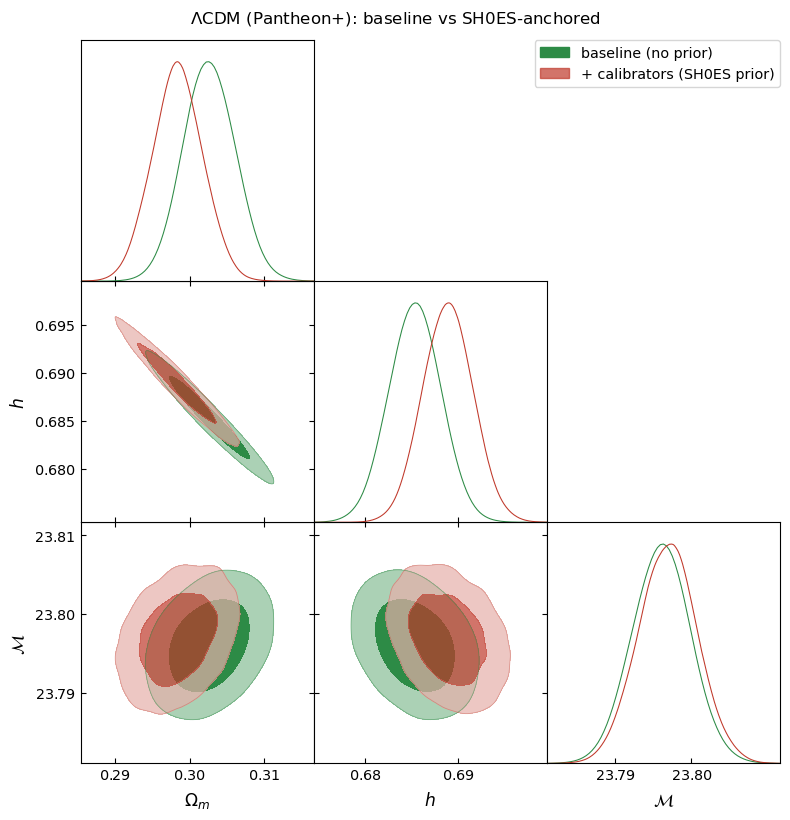

In [48]:
# ── 3.1 (cont.) LCDM Pantheon+ — SH0ES-anchored (calibrators as prior) ──────
prior_lcdm_anc = Prior()
prior_lcdm_anc.add_parameter('om',   dist=(0.1, 0.5))
prior_lcdm_anc.add_parameter('h',    dist=(0.55, 0.85))
prior_lcdm_anc.add_parameter('obh2', dist=(0.02, 0.025))
prior_lcdm_anc.add_parameter('Mcal', dist=(23.0, 24.5))
def ll_lcdm_anc(p):
    om, h, obh2, Mcal = p['om'], p['h'], p['obh2'], p['Mcal']
    M_abs = Mcal - 5.0*np.log10(cH0/h) - 25.0
    chi2 = (chi2_snia_physical(M_abs, om, h, -1, 0)
            + chi2_bao_desi(om, obh2, h, -1, 0)
            + chi2_cmb(om, obh2, h, -1, 0)
            + chi2_cc(om, h, -1, 0)
            + chi2_calibrators(M_abs))
    return -0.5*chi2
sampler_lcdm_anc = Sampler(prior_lcdm_anc, ll_lcdm_anc, n_live=1500)
sampler_lcdm_anc.run(verbose=True)
pts_lcdm_anc, _lw, _ = sampler_lcdm_anc.posterior()
w_lcdm_anc = np.exp(_lw-_lw.max()); w_lcdm_anc /= w_lcdm_anc.sum()
print(f'LCDM anchored: log Z = {sampler_lcdm_anc.log_z:.2f}')
print_results('LCDM Pantheon+ + calibrators (SH0ES-anchored)', pts_lcdm_anc, w_lcdm_anc, ['om','h','obh2','Mcal'], ['om','h','obh2','Mcal'])

s_lcdm_anc = MCSamples(samples=pts_lcdm_anc, weights=w_lcdm_anc, names=['om','h','obh2','Mcal'], labels=[r'\Omega_m','h',r'\omega_b',r'\mathcal{M}'],
                      settings={'smooth_scale_2D': 0.3, 'smooth_scale_1D': 0.3})
g = plots.get_subplot_plotter(width_inch=8)
g.settings.alpha_filled_add = 0.7; g.settings.axes_fontsize = 12; g.settings.lab_fontsize = 14
g.triangle_plot([s_lcdm, s_lcdm_anc], ['om','h','Mcal'], filled=True,
                legend_labels=['baseline (no prior)', '+ calibrators (SH0ES prior)'],
                contour_colors=['#2D8B46', '#C0392B'], markers={'h': 0.7304})
plt.suptitle(r'$\Lambda$CDM (Pantheon+): baseline vs SH0ES-anchored', y=1.02)
plt.savefig('LCDM_anchored_contour.pdf', dpi=300, bbox_inches='tight'); plt.show()


## 3.2 DES-Dovekie


Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 24     | 1        | 4        | 38600    | N/A    | 10137 | -849.66  

══════════════════════════════════════════════════════════
  ΛCDM — DES-Dovekie + DESI DR2 + CMB
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                 Ω_m     0.3028   +0.0035   -0.0035
                   h     0.6851   +0.0028   -0.0027
                 ω_b     0.0225   +0.0001   -0.0001
──────────────────────────────────────────────────────────
Removed no burn in


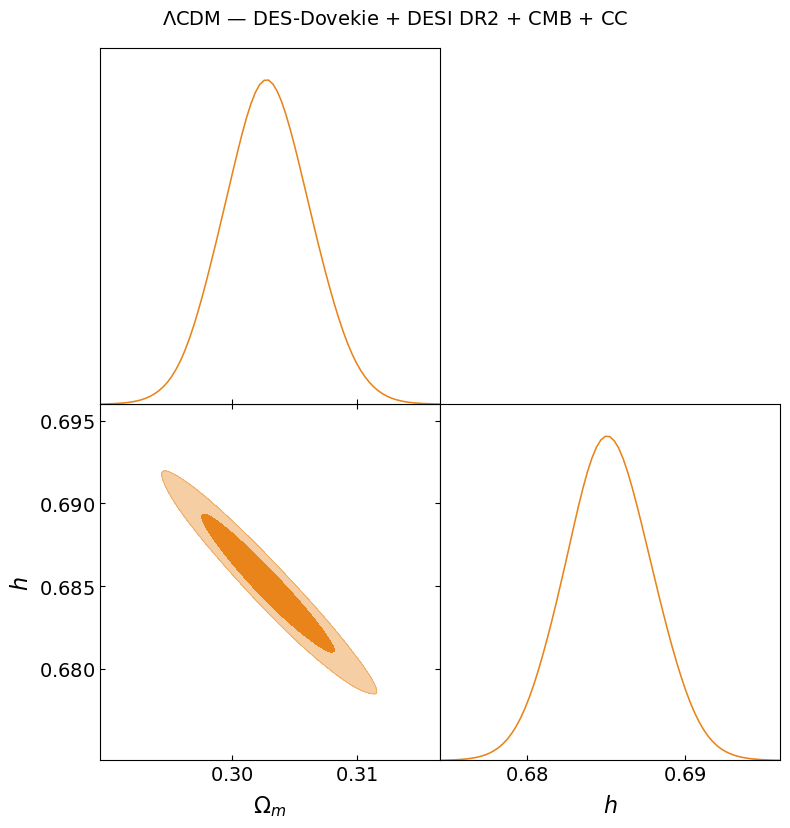

In [49]:
if DES_LOADED:
    prior_lcdm_des = Prior()
    prior_lcdm_des.add_parameter('om',   dist=(0.1, 0.5))
    prior_lcdm_des.add_parameter('h',    dist=(0.55, 0.85))
    prior_lcdm_des.add_parameter('obh2', dist=(0.02, 0.025))

    def log_like_lcdm_des(params):
        om, h, obh2 = params['om'], params['h'], params['obh2']
        chi2 = (chi2_des(om, h, -1, 0)
                + chi2_bao_desi(om, obh2, h, -1, 0)
                + chi2_cmb(om, obh2, h, -1, 0)
                + chi2_cc(om, h, -1, 0)
                )
        return -0.5 * chi2

    sampler_lcdm_des = Sampler(prior_lcdm_des, log_like_lcdm_des, n_live=1500)
    sampler_lcdm_des.run(verbose=True)
    pts_ld, lw_ld, ll_ld = sampler_lcdm_des.posterior()
    w_ld = np.exp(lw_ld - lw_ld.max()); w_ld /= w_ld.sum()

    res_ld = print_results('ΛCDM — DES-Dovekie + DESI DR2 + CMB',
        pts_ld, w_ld, ['om','h','obh2'], ['Ω_m','h','ω_b'])

    s_dov = MCSamples(samples=pts_ld, weights=w_ld,
        names=['om','h','obh2'], labels=[r'\Omega_m','h',r'\omega_b'],
        settings={'smooth_scale_2D': -1, 'smooth_scale_1D': -1,
                  'fine_bins': 256, 'fine_bins_2D': 256})
    g = plots.get_subplot_plotter(width_inch=8)
    g.settings.alpha_filled_add = 0.7
    g.settings.axes_fontsize = 14; g.settings.lab_fontsize = 16
    g.triangle_plot(s_dov, ['om','h'], filled=True, contour_colors=['#E8841A'])
    plt.suptitle(r'$\Lambda$CDM — DES-Dovekie + DESI DR2 + CMB + CC', fontsize=14, y=1.03)
    plt.savefig('LCDM_DES_corner.pdf', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('DES-Dovekie not loaded — skipping.')


## 3.3 Partial data combinations

The full combination (SNIa + DESI DR2 + CMB + CC) above constrains $(\Omega_m, h)$ tightly because each probe restricts a *different* direction in parameter space. To make that explicit we now fit **flat ΛCDM** to the individual probes in isolation.

- **SNIa-only** measures the shape of the distance–redshift relation but is blind to the absolute scale: with a free (Pantheon+) or analytically marginalized (DES) absolute magnitude, $h$ is fully degenerate with $\mathcal{M}$ and its posterior is essentially flat across the prior. This is *expected* — it is the physical point of the figures below.
- **BAO-only** (DESI DR2) constrains $\Omega_m$ and the combination $H_0 r_d$; with a narrow BBN-like $\omega_b$ prior it pins $\Omega_m$ near the DESI value.
- **BAO + CMB** adds the high-redshift acoustic scale, tightening both $\Omega_m$ and $h$.

These fits are **parameter-constraint only**: they produce no Bayesian-evidence rows and do not enter the §8 $\Delta\ln Z$ table. The full-combination results from §3.1–§3.2 are reused unchanged.

### (a) ΛCDM — SNIa-only (Pantheon+)

Parameters: $(\Omega_m, h, \mathcal{M})$.  
`chi2_snia_physical` takes no $\omega_b$; $h$ is degenerate with $\mathcal{M}$.

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 17     | 1        | 4        | 28100    | N/A    | 10139 | -735.43  

══════════════════════════════════════════════════════════
  ΛCDM — SNIa-only (Pantheon+)
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                 Ω_m     0.3345   +0.0183   -0.0181
                   h     0.7008   +0.1018   -0.1022
               M_cal    23.8065   +0.0069   -0.0069
──────────────────────────────────────────────────────────
Removed no burn in


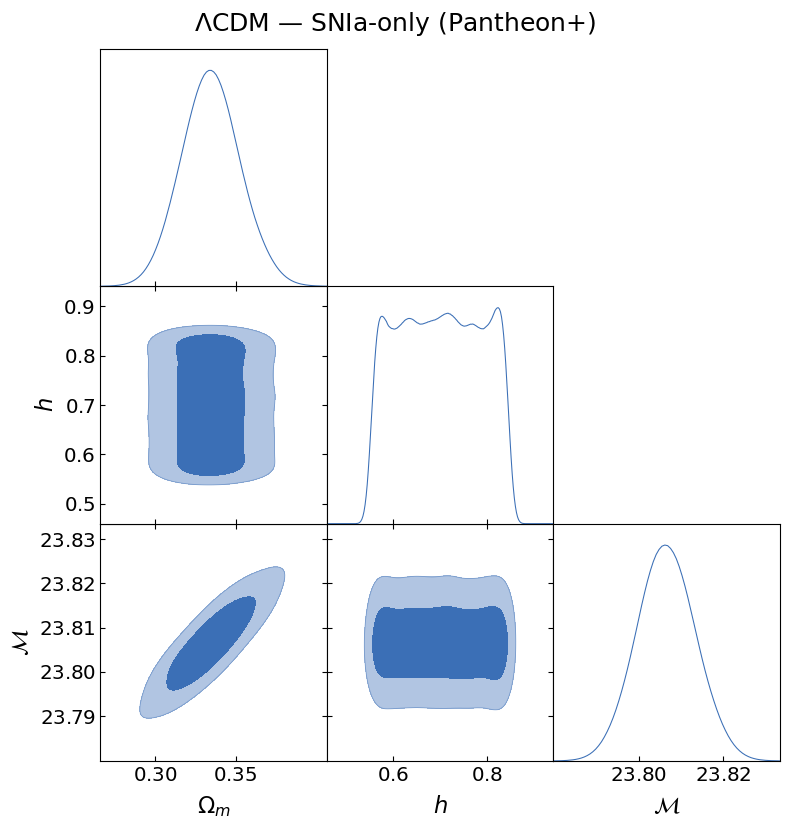

In [50]:
prior_sn_pp = Prior()
prior_sn_pp.add_parameter('om',   dist=(0.1, 0.5))
prior_sn_pp.add_parameter('h',    dist=(0.55, 0.85))
prior_sn_pp.add_parameter('Mcal', dist=(23.0, 24.5))

def log_like_lcdm_snia_pp(params):
    om, h, Mcal = params['om'], params['h'], params['Mcal']
    M_abs = Mcal - 5.0 * np.log10(cH0 / h) - 25.0
    chi2 = chi2_snia_physical(M_abs, om, h, -1, 0)
    return -0.5 * chi2

sampler_sn_pp = Sampler(prior_sn_pp, log_like_lcdm_snia_pp, n_live=1500)
sampler_sn_pp.run(verbose=True)
pts_sn_pp, lw_sn_pp, ll_sn_pp = sampler_sn_pp.posterior()
w_sn_pp = np.exp(lw_sn_pp - lw_sn_pp.max()); w_sn_pp /= w_sn_pp.sum()

res_sn_pp = print_results('ΛCDM — SNIa-only (Pantheon+)',
    pts_sn_pp, w_sn_pp, ['om','h','Mcal'], ['Ω_m','h','M_cal'])

s_sn_pp = MCSamples(samples=pts_sn_pp, weights=w_sn_pp,
    names=['om','h','Mcal'], labels=[r'\Omega_m','h',r'\mathcal{M}'],
    settings={'smooth_scale_2D': -1, 'smooth_scale_1D': -1,
              'fine_bins': 256, 'fine_bins_2D': 256})
g = plots.get_subplot_plotter(width_inch=8)
g.settings.alpha_filled_add = 0.7
g.settings.axes_fontsize=16; g.settings.lab_fontsize=18
g.triangle_plot(s_sn_pp, ['om','h','Mcal'], filled=True, contour_colors=['#3B6FB6'])
plt.suptitle(r'$\Lambda$CDM — SNIa-only (Pantheon+)', fontsize=18, y=1.03)
plt.savefig('LCDM_SNIa_only_PP_corner.pdf', dpi=300, bbox_inches='tight')
plt.show()

### (b) ΛCDM — SNIa-only (DES-Dovekie) : params (Ω_m, h)
M analytically marginalized inside chi2_des → no M_cal, no ω_b. h again flat.

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 10     | 1        | 4        | 18900    | N/A    | 10073 | -822.47  

══════════════════════════════════════════════════════════
  ΛCDM — SNIa-only (DES-Dovekie)
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                 Ω_m     0.3307   +0.0152   -0.0154
                   h     0.7008   +0.1014   -0.1012
──────────────────────────────────────────────────────────
Removed no burn in


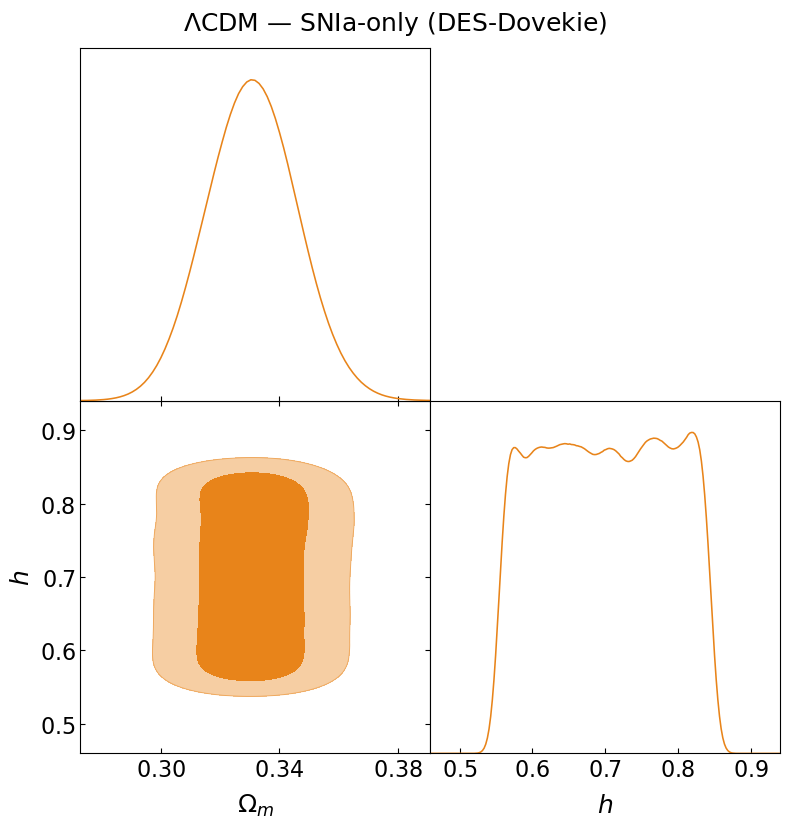

In [51]:
if DES_LOADED:
    prior_sn_des = Prior()
    prior_sn_des.add_parameter('om', dist=(0.1, 0.5))
    prior_sn_des.add_parameter('h',  dist=(0.55, 0.85))

    def log_like_lcdm_snia_des(params):
        om, h = params['om'], params['h']
        chi2 = chi2_des(om, h, -1, 0)
        return -0.5 * chi2

    sampler_sn_des = Sampler(prior_sn_des, log_like_lcdm_snia_des, n_live=1500)
    sampler_sn_des.run(verbose=True)
    pts_sn_des, lw_sn_des, ll_sn_des = sampler_sn_des.posterior()
    w_sn_des = np.exp(lw_sn_des - lw_sn_des.max()); w_sn_des /= w_sn_des.sum()

    res_sn_des = print_results('ΛCDM — SNIa-only (DES-Dovekie)',
        pts_sn_des, w_sn_des, ['om','h'], ['Ω_m','h'])

    s_sn_des = MCSamples(samples=pts_sn_des, weights=w_sn_des,
        names=['om','h'], labels=[r'\Omega_m','h'],
        settings={'smooth_scale_2D': -1, 'smooth_scale_1D': -1,
                  'fine_bins': 256, 'fine_bins_2D': 256})
    g = plots.get_subplot_plotter(width_inch=8)
    g.settings.alpha_filled_add = 0.7
    g.settings.axes_fontsize=16; g.settings.lab_fontsize=18
    g.triangle_plot(s_sn_des, ['om','h'], filled=True, contour_colors=['#E8841A'])
    plt.suptitle(r'$\Lambda$CDM — SNIa-only (DES-Dovekie)', fontsize=18, y=1.03)
    plt.savefig('LCDM_SNIa_only_DES_corner.pdf', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('DES-Dovekie not loaded — skipping SNIa-only (DES).')

### (c) ΛCDM — BAO-only (DESI DR2) : params (Ω_m, h, ω_b)
Constrains Ω_m and the H0·r_d combination; narrow BBN-like ω_b prior fixes r_d scale.

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 16     | 1        | 4        | 26300    | N/A    | 10033 | -11.65   

══════════════════════════════════════════════════════════
  ΛCDM — BAO-only (DESI DR2)
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                 Ω_m     0.2972   +0.0084   -0.0083
                   h     0.6898   +0.0137   -0.0140
                 ω_b     0.0226   +0.0017   -0.0017
──────────────────────────────────────────────────────────
Removed no burn in


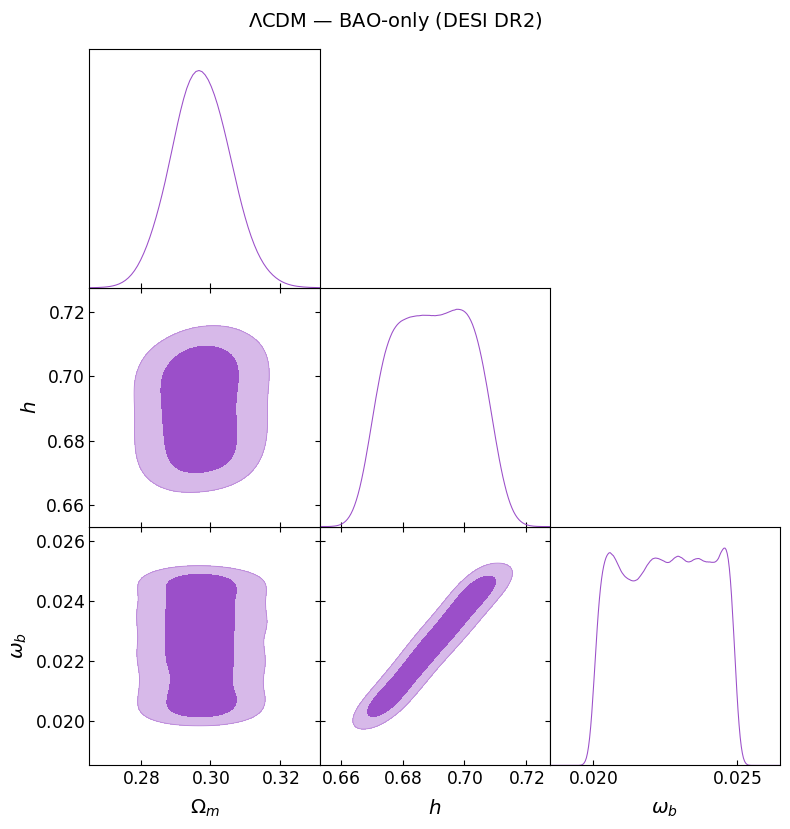

In [52]:
prior_bao = Prior()
prior_bao.add_parameter('om',   dist=(0.1, 0.5))
prior_bao.add_parameter('h',    dist=(0.55, 0.85))
prior_bao.add_parameter('obh2', dist=(0.020, 0.025))

def log_like_lcdm_bao(params):
    om, h, obh2 = params['om'], params['h'], params['obh2']
    chi2 = chi2_bao_desi(om, obh2, h, -1, 0)
    return -0.5 * chi2

sampler_bao = Sampler(prior_bao, log_like_lcdm_bao, n_live=1500)
sampler_bao.run(verbose=True)
pts_bao, lw_bao, ll_bao = sampler_bao.posterior()
w_bao = np.exp(lw_bao - lw_bao.max()); w_bao /= w_bao.sum()

res_bao = print_results('ΛCDM — BAO-only (DESI DR2)',
    pts_bao, w_bao, ['om','h','obh2'], ['Ω_m','h','ω_b'])

s_bao = MCSamples(samples=pts_bao, weights=w_bao,
    names=['om','h','obh2'], labels=[r'\Omega_m','h',r'\omega_b'],
    settings={'smooth_scale_2D': -1, 'smooth_scale_1D': -1,
              'fine_bins': 256, 'fine_bins_2D': 256})
g = plots.get_subplot_plotter(width_inch=8)
g.settings.alpha_filled_add = 0.7
g.settings.axes_fontsize = 14; g.settings.lab_fontsize = 16
g.triangle_plot(s_bao, ['om','h','obh2'], filled=True, contour_colors=['#9B4FC9'])
plt.suptitle(r'$\Lambda$CDM — BAO-only (DESI DR2)', fontsize=14, y=1.03)
plt.savefig('LCDM_BAO_only_corner.pdf', dpi=300, bbox_inches='tight')
plt.show()

### (d) ΛCDM — BAO + CMB : params (Ω_m, h, ω_b)
No SNIa here, so there is a single version (independent of the SNIa sample).

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 24     | 1        | 4        | 38300    | N/A    | 10148 | -20.31   

══════════════════════════════════════════════════════════
  ΛCDM — BAO + CMB
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                 Ω_m     0.3012   +0.0035   -0.0035
                   h     0.6863   +0.0028   -0.0028
                 ω_b     0.0225   +0.0001   -0.0001
──────────────────────────────────────────────────────────
Removed no burn in


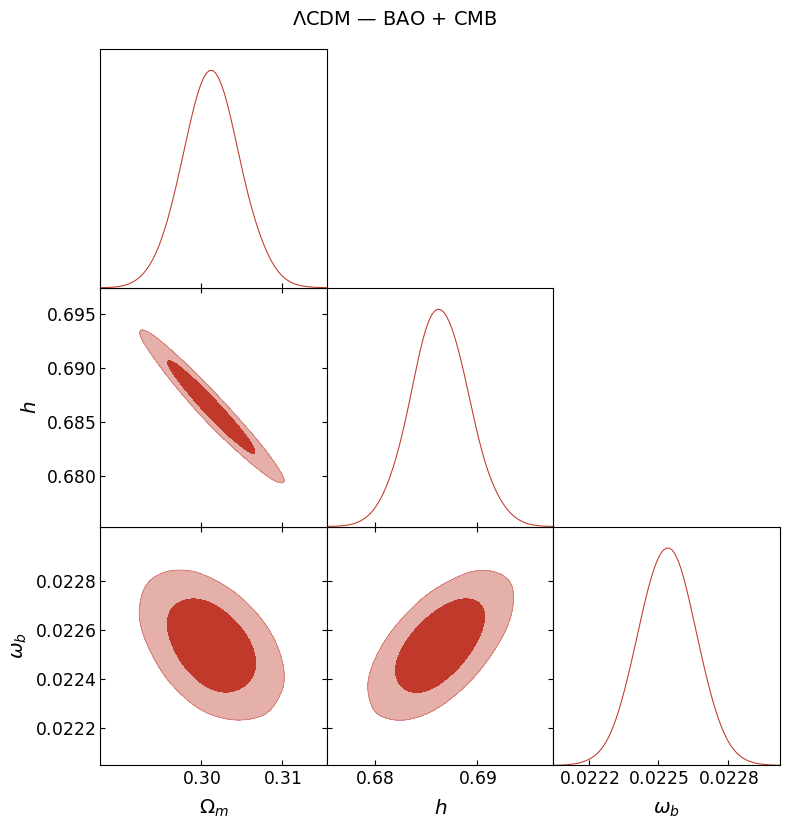

In [53]:
prior_baocmb = Prior()
prior_baocmb.add_parameter('om',   dist=(0.1, 0.5))
prior_baocmb.add_parameter('h',    dist=(0.55, 0.85))
prior_baocmb.add_parameter('obh2', dist=(0.020, 0.025))

def log_like_lcdm_baocmb(params):
    om, h, obh2 = params['om'], params['h'], params['obh2']
    chi2 = (chi2_bao_desi(om, obh2, h, -1, 0)
            + chi2_cmb(om, obh2, h, -1, 0))
    return -0.5 * chi2

sampler_baocmb = Sampler(prior_baocmb, log_like_lcdm_baocmb, n_live=1500)
sampler_baocmb.run(verbose=True)
pts_baocmb, lw_baocmb, ll_baocmb = sampler_baocmb.posterior()
w_baocmb = np.exp(lw_baocmb - lw_baocmb.max()); w_baocmb /= w_baocmb.sum()

res_baocmb = print_results('ΛCDM — BAO + CMB',
    pts_baocmb, w_baocmb, ['om','h','obh2'], ['Ω_m','h','ω_b'])

s_baocmb = MCSamples(samples=pts_baocmb, weights=w_baocmb,
    names=['om','h','obh2'], labels=[r'\Omega_m','h',r'\omega_b'],
    settings={'smooth_scale_2D': -1, 'smooth_scale_1D': -1,
              'fine_bins': 256, 'fine_bins_2D': 256})
g = plots.get_subplot_plotter(width_inch=8)
g.settings.alpha_filled_add = 0.7
g.settings.axes_fontsize = 14; g.settings.lab_fontsize = 16
g.triangle_plot(s_baocmb, ['om','h','obh2'], filled=True, contour_colors=['#C0392B'])
plt.suptitle(r'$\Lambda$CDM — BAO + CMB', fontsize=14, y=1.03)
plt.savefig('LCDM_BAO_CMB_corner.pdf', dpi=300, bbox_inches='tight')
plt.show()

### (e) Degeneracy-breaking figure (Pantheon+ fiducial)
Two panels: (left) full (Ω_m, h) view — SNIa-only is a vertical band (flat in h), while BAO+CMB and the full combination are tiny tight contours marked by a dashed box; (right) a zoom on that box so the two tight contours are properly resolved and their intersection with the SNIa band is visible. (A single shared axis would shrink them to invisibility, which is why we zoom rather than plot a marker bigger than the contour.) The combined contour reuses pts_lcdm / w_lcdm from §3.1 (full, UNCHANGED). The zoom window is set automatically from the two tight posteriors, so it adapts to the actual fit (e.g. when the CC-included full result shifts Ω_m).

**Degeneracy breaking.** Overlaying the SNIa-only and BAO + CMB posteriors in the $(\Omega_m, h)$ plane shows how their degeneracy directions intersect. SNIa-only is a vertical *band* (it fixes $\Omega_m$ but is flat in $h$), whereas BAO + CMB and the full combination are very tightly constrained — so tightly that they would be invisible next to the SNIa band on a shared axis. The figure therefore uses **two panels**: a *full view* (left) with a dashed box marking where the tight contours live, and a *zoom* (right) that resolves the BAO + CMB and full contours and shows them sitting at the intersection with the SNIa band. The combined contour is reused from §3.1 (full result, *unchanged*); the tight full-combination constraint is produced by the *complementarity* of the probes, not by any single one.

Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 600x450 with 0 Axes>

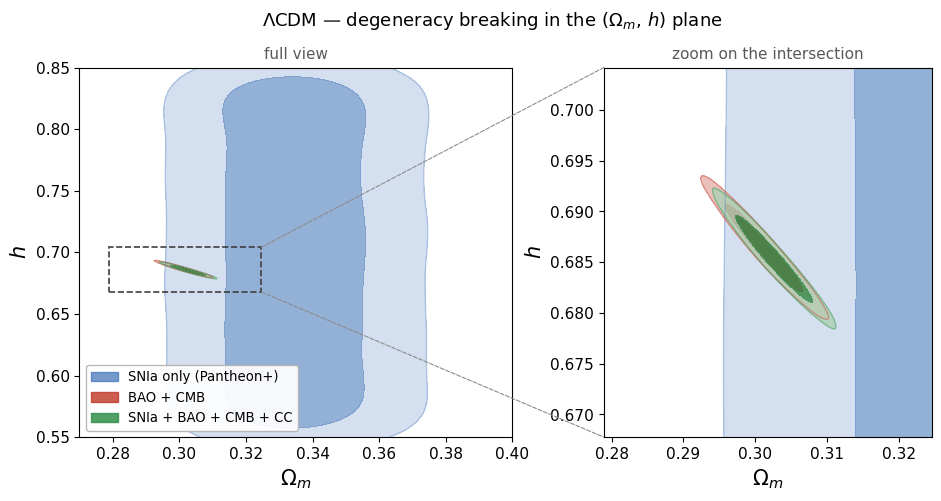

In [54]:
import matplotlib.patches as mpatches
from matplotlib.patches import ConnectionPatch, Rectangle

_oh_set = {'smooth_scale_2D': -1, 'smooth_scale_1D': -1, 'fine_bins': 256, 'fine_bins_2D': 256}

def _wstd(pts, w, i):
    m = np.average(pts[:, i], weights=w)
    return m, np.sqrt(np.average((pts[:, i] - m) ** 2, weights=w))

s_sn_oh  = MCSamples(samples=pts_sn_pp[:, :2],  weights=w_sn_pp,  names=['om','h'],
    labels=[r'\Omega_m','h'], settings=_oh_set)
s_bc_oh  = MCSamples(samples=pts_baocmb[:, :2], weights=w_baocmb, names=['om','h'],
    labels=[r'\Omega_m','h'], settings=_oh_set)
s_all_oh = MCSamples(samples=pts_lcdm[:, :2],   weights=w_lcdm,   names=['om','h'],
    labels=[r'\Omega_m','h'], settings=_oh_set)

# auto zoom window: median ± 5σ over the two tight posteriors, plus a small pad
_oms = [_wstd(p, w, 0) for p, w in [(pts_baocmb, w_baocmb), (pts_lcdm, w_lcdm)]]
_hs  = [_wstd(p, w, 1) for p, w in [(pts_baocmb, w_baocmb), (pts_lcdm, w_lcdm)]]
zx0 = min(m - 5*s for m, s in _oms); zx1 = max(m + 5*s for m, s in _oms)
zy0 = min(m - 5*s for m, s in _hs);  zy1 = max(m + 5*s for m, s in _hs)
_px = 0.12 * (zx1 - zx0); _py = 0.12 * (zy1 - zy0)
zx0 -= _px; zx1 += _px; zy0 -= _py; zy1 += _py

g = plots.get_single_plotter()
fig = plt.figure(figsize=(11, 4.8))
gs = fig.add_gridspec(1, 2, width_ratios=[1.32, 1], wspace=0.24)
axM = fig.add_subplot(gs[0, 0]); axZ = fig.add_subplot(gs[0, 1])
_cols = ['#3B6FB6', '#C0392B', '#2D8B46']; _al = [0.55, 0.78, 0.78]
for ax in (axM, axZ):
    for s, col, al in zip([s_sn_oh, s_bc_oh, s_all_oh], _cols, _al):
        g.add_2d_contours(s, 'om', 'h', ax=ax, filled=True, color=col, alpha=al)
axM.set_xlim(0.27, 0.40); axM.set_ylim(0.55, 0.85)
axZ.set_xlim(zx0, zx1);   axZ.set_ylim(zy0, zy1)
for ax in (axM, axZ):
    ax.set_xlabel(r'$\Omega_m$', fontsize=15); ax.set_ylabel(r'$h$', fontsize=15)
    ax.tick_params(labelsize=11)
axM.add_patch(Rectangle((zx0, zy0), zx1 - zx0, zy1 - zy0,
                        fill=False, ec='0.25', lw=1.2, ls='--', zorder=20))
# connectors: main rectangle RIGHT edge -> zoom LEFT edge
for _a, _b in [((zx1, zy1), (zx0, zy1)), ((zx1, zy0), (zx0, zy0))]:
    fig.add_artist(ConnectionPatch(xyA=_a, coordsA=axM.transData,
                                   xyB=_b, coordsB=axZ.transData,
                                   color='0.55', lw=0.8, ls='--'))
axM.set_title('full view', fontsize=11, color='0.35')
axZ.set_title('zoom on the intersection', fontsize=11, color='0.35')
axM.legend(handles=[
    mpatches.Patch(color=_cols[0], alpha=0.70, label='SNIa only (Pantheon+)'),
    mpatches.Patch(color=_cols[1], alpha=0.82, label='BAO + CMB'),
    mpatches.Patch(color=_cols[2], alpha=0.82, label='SNIa + BAO + CMB + CC'),
], loc='lower left', fontsize=9.5, framealpha=0.92, facecolor='white', edgecolor='0.7')
fig.suptitle(r'$\Lambda$CDM — degeneracy breaking in the $(\Omega_m,\,h)$ plane',
             fontsize=13, y=1.0)
fig.savefig('LCDM_degeneracy_breaking.pdf', bbox_inches='tight')
plt.show()

### (f) SNIa-sample comparison: Pantheon+ vs DES-Dovekie in (Ω_m, h) ───────
Two overlapping vertical bands (h flat for both samples); dashed lines mark the median Ω_m of each. Single 2D panel with fixed limits + no-smoothing settings so the flat-h posteriors render robustly.

Removed no burn in
Removed no burn in


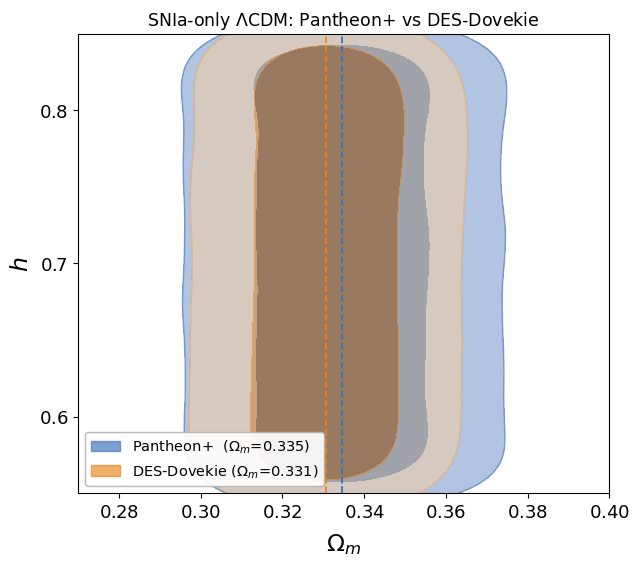

In [55]:
import matplotlib.patches as mpatches

if DES_LOADED:
    _oh_set = {'smooth_scale_2D': -1, 'smooth_scale_1D': -1, 'fine_bins': 256, 'fine_bins_2D': 256}

    def _wmed(pts, w, i):
        idx = np.argsort(pts[:, i]); cw = np.cumsum(w[idx] / w.sum())
        return pts[idx[np.searchsorted(cw, 0.5)], i]

    s_pp_oh  = MCSamples(samples=pts_sn_pp[:, :2], weights=w_sn_pp,  names=['om','h'],
        labels=[r'\Omega_m','h'], settings=_oh_set)
    s_des_oh = MCSamples(samples=pts_sn_des,       weights=w_sn_des, names=['om','h'],
        labels=[r'\Omega_m','h'], settings=_oh_set)

    g = plots.get_single_plotter(width_inch=6.5, ratio=0.85)
    g.settings.alpha_filled_add = 0.55
    g.settings.axes_fontsize = 13; g.settings.lab_fontsize = 17
    g.plot_2d([s_pp_oh, s_des_oh], 'om', 'h', filled=True,
        colors=['#3B6FB6', '#E8841A'], lims=[0.27, 0.40, 0.55, 0.85])
    ax = g.subplots[0, 0]
    om_pp  = _wmed(pts_sn_pp,  w_sn_pp,  0)
    om_des = _wmed(pts_sn_des, w_sn_des, 0)
    ax.axvline(om_pp,  color='#3B6FB6', ls='--', lw=1.3, zorder=9)
    ax.axvline(om_des, color='#E8841A', ls='--', lw=1.3, zorder=9)
    ax.legend(handles=[
        mpatches.Patch(color='#3B6FB6', alpha=0.65, label=f'Pantheon+  ($\\Omega_m$={om_pp:.3f})'),
        mpatches.Patch(color='#E8841A', alpha=0.65, label=f'DES-Dovekie ($\\Omega_m$={om_des:.3f})'),
    ], loc='lower left', fontsize=10.5, framealpha=0.92, facecolor='white', edgecolor='0.7')
    ax.set_title(r'SNIa-only $\Lambda$CDM: Pantheon+ vs DES-Dovekie', fontsize=12.5)
    g.export('LCDM_snia_PP_vs_DES.pdf')
    plt.show()
else:
    print('DES-Dovekie not loaded — skipping SNIa PP vs DES comparison.')

### (g) Compact summary: marginalized Ω_m (and h where constrained)
DESI DR2 BAO published flat-ΛCDM Ω_m (BAO+BBN), arXiv:2503.14738, for sanity check.

In [56]:
DESI_DR2_OM, DESI_DR2_OM_ERR = 0.2975, 0.0086

def _fmt(res, key):
    if key in res:
        m, hi, lo = res[key]
        return f'{m:.4f} +{hi:.4f}/-{lo:.4f}'
    return '—'

print('═' * 80)
print('  ΛCDM — marginalized parameters: partial vs full data combinations')
print('═' * 80)
print(f'  {"Combination":<28s} {"Ω_m":<26s} {"h":<22s}')
print('  ' + '─' * 76)
# SNIa-only: h flat (M–h degeneracy) → reported as unconstrained, not a number
print(f'  {"SNIa-only (Pantheon+)":<28s} {_fmt(res_sn_pp,"om"):<26s} {"flat (M–h degeneracy)":<22s}')
if DES_LOADED:
    print(f'  {"SNIa-only (DES-Dovekie)":<28s} {_fmt(res_sn_des,"om"):<26s} {"flat (M–h degeneracy)":<22s}')
# BAO-only and BAO+CMB: h constrained
print(f'  {"BAO-only (DESI DR2)":<28s} {_fmt(res_bao,"om"):<26s} {_fmt(res_bao,"h"):<22s}')
print(f'  {"BAO + CMB":<28s} {_fmt(res_baocmb,"om"):<26s} {_fmt(res_baocmb,"h"):<22s}')
# Full combinations (reused from §3.1–§3.2, unchanged)
print(f'  {"Full SNIa+BAO+CMB+CC (PP)":<28s} {_fmt(res_lcdm,"om"):<26s} {_fmt(res_lcdm,"h"):<22s}')
if DES_LOADED:
    print(f'  {"Full SNIa+BAO+CMB+CC (DES)":<28s} {_fmt(res_ld,"om"):<26s} {_fmt(res_ld,"h"):<22s}')
print('  ' + '─' * 76)
print('  BAO-only sanity check vs DESI DR2 published flat-ΛCDM Ω_m:')
print(f'    this work : Ω_m = {_fmt(res_bao,"om")}')
print(f'    DESI DR2  : Ω_m = {DESI_DR2_OM:.4f} ± {DESI_DR2_OM_ERR:.4f}  (arXiv:2503.14738)')
print(f'    agreement : {abs(res_bao["om"][0] - DESI_DR2_OM) / DESI_DR2_OM_ERR:.2f}σ')
print('═' * 80)

════════════════════════════════════════════════════════════════════════════════
  ΛCDM — marginalized parameters: partial vs full data combinations
════════════════════════════════════════════════════════════════════════════════
  Combination                  Ω_m                        h                     
  ────────────────────────────────────────────────────────────────────────────
  SNIa-only (Pantheon+)        0.3345 +0.0183/-0.0181     flat (M–h degeneracy) 
  SNIa-only (DES-Dovekie)      0.3307 +0.0152/-0.0154     flat (M–h degeneracy) 
  BAO-only (DESI DR2)          0.2972 +0.0084/-0.0083     0.6898 +0.0137/-0.0140
  BAO + CMB                    0.3012 +0.0035/-0.0035     0.6863 +0.0028/-0.0028
  Full SNIa+BAO+CMB+CC (PP)    0.3026 +0.0036/-0.0035     0.6854 +0.0028/-0.0028
  Full SNIa+BAO+CMB+CC (DES)   0.3028 +0.0035/-0.0035     0.6851 +0.0028/-0.0027
  ────────────────────────────────────────────────────────────────────────────
  BAO-only sanity check vs DESI DR2 published

---
# 4. $w$CDM

Parameters: $(\Omega_m, h, \omega_b, w_0, \mathcal{M})$


## 4.1 Pantheon+


Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 36     | 1        | 4        | 59000    | N/A    | 12252 | -766.03  

══════════════════════════════════════════════════════════
  wCDM — SNIa + BAO + CMB +CC
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                 Ω_m     0.3057   +0.0050   -0.0051
                   h     0.6809   +0.0057   -0.0056
                 ω_b     0.0226   +0.0001   -0.0001
                  w₀    -0.9797   +0.0230   -0.0230
               M_cal    23.8004   +0.0063   -0.0063
──────────────────────────────────────────────────────────
Removed no burn in


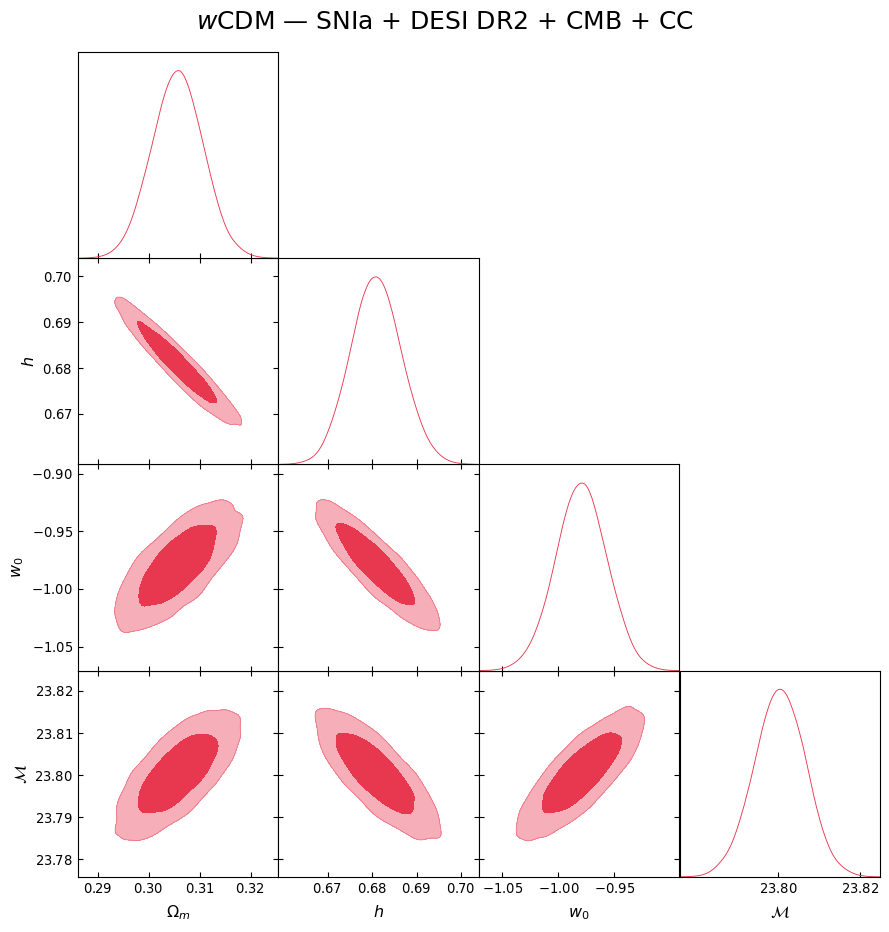

In [57]:
prior_wcdm = Prior()
prior_wcdm.add_parameter('om',   dist=(0.1,  0.5))
prior_wcdm.add_parameter('h',    dist=(0.55, 0.85))
prior_wcdm.add_parameter('obh2', dist=(0.02, 0.025))
prior_wcdm.add_parameter('w0',   dist=(-2.5, 0.0))
prior_wcdm.add_parameter('Mcal', dist=(23.0, 24.5))

def log_like_wcdm_combined(params):
    om, h, obh2, w0, Mcal = (params['om'], params['h'], params['obh2'],
                              params['w0'], params['Mcal'])
    M_abs = Mcal - 5.0 * np.log10(cH0 / h) - 25.0
    chi2 = (chi2_snia_physical(M_abs, om, h, w0, 0)
            + chi2_bao_desi(om, obh2, h, w0, 0)
            + chi2_cmb(om, obh2, h, w0, 0)
            + chi2_cc(om, h, w0, 0)
            )
    return -0.5 * chi2

sampler_wcdm = Sampler(prior_wcdm, log_like_wcdm_combined, n_live=1500)
sampler_wcdm.run(verbose=True)
pts_wcdm, lw_wcdm, ll_wcdm = sampler_wcdm.posterior()
w_wcdm = np.exp(lw_wcdm - lw_wcdm.max()); w_wcdm /= w_wcdm.sum()

res_wcdm = print_results('wCDM — SNIa + BAO + CMB +CC',
    pts_wcdm, w_wcdm, ['om','h','obh2','w0','Mcal'],
    ['Ω_m','h','ω_b','w₀','M_cal'])

s_wcdm = MCSamples(samples=pts_wcdm, weights=w_wcdm,
    names=['om','h','obh2','w0','Mcal'],
    labels=[r'\Omega_m','h',r'\omega_b',r'w_0',r'\mathcal{M}'],
    settings={'smooth_scale_2D': 0.3, 'smooth_scale_1D': 0.3})

g = plots.get_subplot_plotter(width_inch=9)
g.settings.alpha_filled_add = 0.7
g.settings.axes_fontsize=12
g.settings.lab_fontsize=14

g.triangle_plot(s_wcdm, ['om','h','w0','Mcal'], filled=True, contour_colors=['#E8384F'])
plt.suptitle(r'$w$CDM — SNIa + DESI DR2 + CMB + CC', fontsize=18, y=1.03)
plt.savefig('wCDM_combined_corner.pdf', dpi=300, bbox_inches='tight')
plt.show()

**§4.1 (cont.)** SH0ES-anchored wCDM.

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 36     | 1        | 4        | 58700    | N/A    | 12187 | -807.69  
wCDM anchored: log Z = -807.69

══════════════════════════════════════════════════════════
  wCDM Pantheon+ + calibrators (SH0ES-anchored)
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                  om     0.2957   +0.0045   -0.0045
                   h     0.6929   +0.0053   -0.0054
                obh2     0.0226   +0.0001   -0.0001
                  w0    -1.0188   +0.0214   -0.0219
                Mcal    23.7927   +0.0060   -0.0061
──────────────────────────────────────────────────────────
Removed no burn in


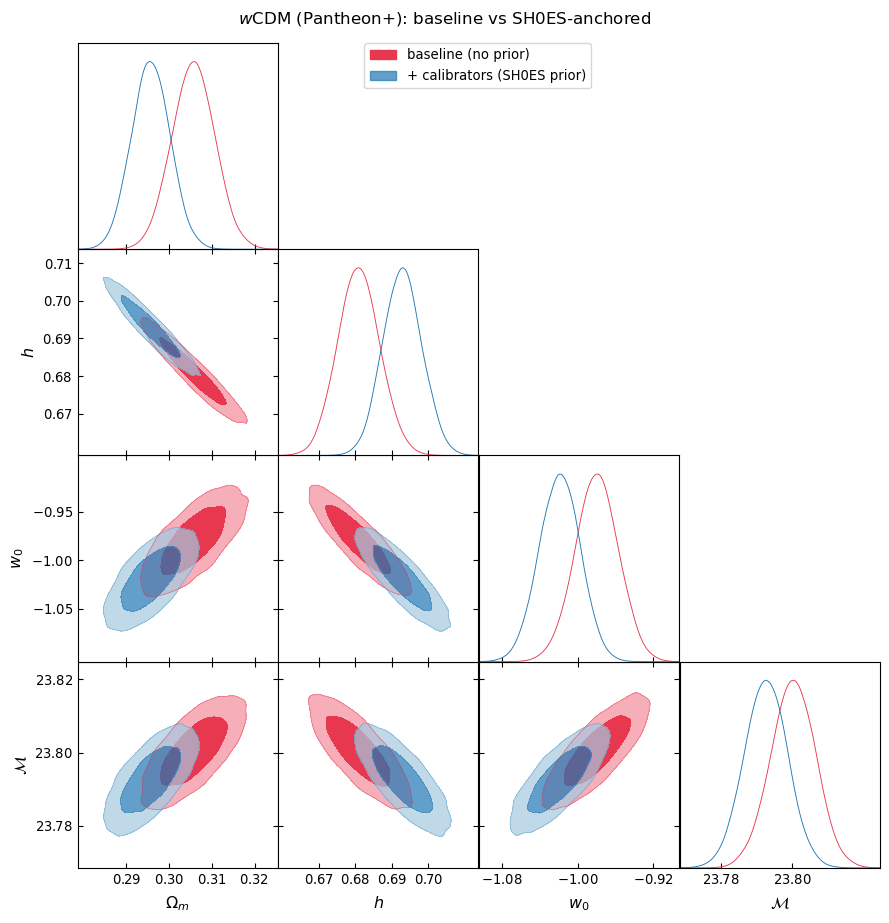

In [58]:
prior_wcdm_anc = Prior()
prior_wcdm_anc.add_parameter('om',   dist=(0.1, 0.5))
prior_wcdm_anc.add_parameter('h',    dist=(0.55, 0.85))
prior_wcdm_anc.add_parameter('obh2', dist=(0.02, 0.025))
prior_wcdm_anc.add_parameter('w0', dist=(-2.5, 0.0))
prior_wcdm_anc.add_parameter('Mcal', dist=(23.0, 24.5))
def ll_wcdm_anc(p):
    om, h, obh2, Mcal = p['om'], p['h'], p['obh2'], p['Mcal']
    w0 = p['w0']
    M_abs = Mcal - 5.0*np.log10(cH0/h) - 25.0
    chi2 = (chi2_snia_physical(M_abs, om, h, w0, 0)
            + chi2_bao_desi(om, obh2, h, w0, 0)
            + chi2_cmb(om, obh2, h, w0, 0)
            + chi2_cc(om, h, w0, 0)
            + chi2_calibrators(M_abs))      # computed geometric M_B prior
    return -0.5*chi2
sampler_wcdm_anc = Sampler(prior_wcdm_anc, ll_wcdm_anc, n_live=1500)
sampler_wcdm_anc.run(verbose=True)
pts_wcdm_anc, _lw, _ = sampler_wcdm_anc.posterior()
w_wcdm_anc = np.exp(_lw-_lw.max()); w_wcdm_anc /= w_wcdm_anc.sum()
print(f'wCDM anchored: log Z = {sampler_wcdm_anc.log_z:.2f}')
print_results('wCDM Pantheon+ + calibrators (SH0ES-anchored)', pts_wcdm_anc, w_wcdm_anc, ['om','h','obh2','w0','Mcal'], ['om','h','obh2','w0','Mcal'])

s_wcdm_anc = MCSamples(samples=pts_wcdm_anc, weights=w_wcdm_anc, names=['om','h','obh2','w0','Mcal'], labels=[r'\Omega_m','h',r'\omega_b',r'w_0',r'\mathcal{M}'],
                      settings={'smooth_scale_2D': 0.3, 'smooth_scale_1D': 0.3})
g = plots.get_subplot_plotter(width_inch=9)
g.settings.alpha_filled_add = 0.7; g.settings.axes_fontsize = 12; g.settings.lab_fontsize = 14
g.triangle_plot([s_wcdm, s_wcdm_anc], ['om','h','w0','Mcal'], filled=True,
                legend_labels=['baseline (no prior)', '+ calibrators (SH0ES prior)'],
                contour_colors=['#E8384F', '#1F77B4'], markers={'h': 0.7304})
plt.suptitle(r'$w$CDM (Pantheon+): baseline vs SH0ES-anchored', y=1.02)
plt.savefig('wCDM_anchored_contour.pdf', dpi=300, bbox_inches='tight'); plt.show()

## 4.2 DES-Dovekie


Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 29     | 1        | 4        | 47800    | N/A    | 11180 | -852.92  

══════════════════════════════════════════════════════════
  wCDM — DES-Dovekie + DESI DR2 + CMB
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                 Ω_m     0.3062   +0.0047   -0.0046
                   h     0.6802   +0.0052   -0.0052
                 ω_b     0.0226   +0.0001   -0.0001
                  w₀    -0.9767   +0.0212   -0.0217
──────────────────────────────────────────────────────────
Removed no burn in


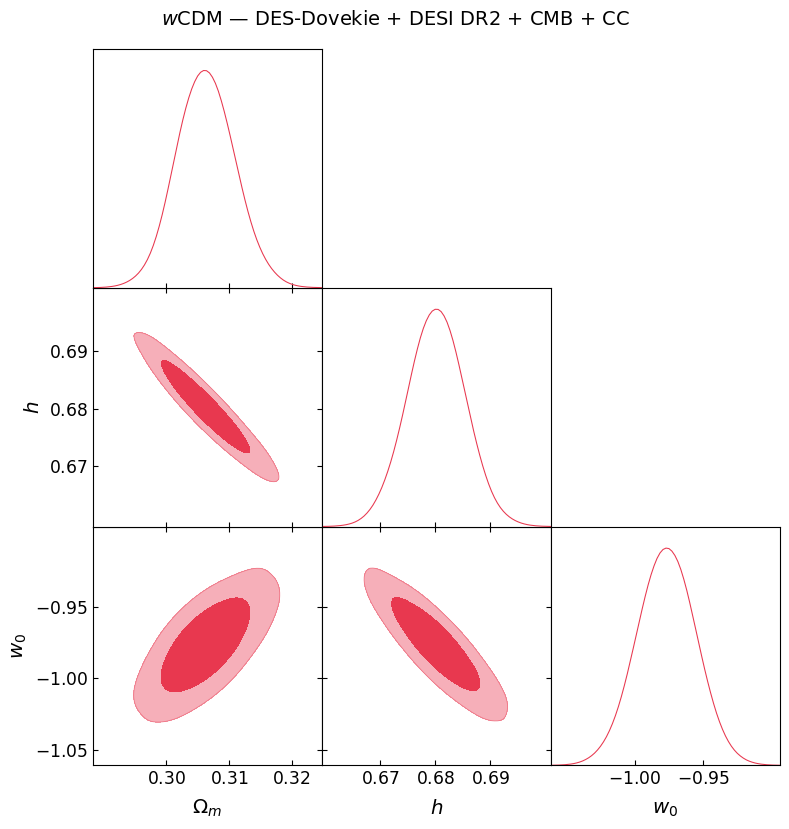

In [59]:
if DES_LOADED:
    prior_wcdm_des = Prior()
    prior_wcdm_des.add_parameter('om',   dist=(0.1, 0.5))
    prior_wcdm_des.add_parameter('h',    dist=(0.55, 0.85))
    prior_wcdm_des.add_parameter('obh2', dist=(0.02, 0.025))
    prior_wcdm_des.add_parameter('w0',   dist=(-2.5, 0.0))
    # No dM parameter — marginalized analytically inside chi2_des

    def log_like_wcdm_des(params):
        om, h, obh2, w0 = (params['om'], params['h'],
                           params['obh2'], params['w0'])
        chi2 = (chi2_des(om, h, w0, 0)
                + chi2_bao_desi(om, obh2, h, w0, 0)
                + chi2_cmb(om, obh2, h, w0, 0)
                + chi2_cc(om, h, w0, 0)
                )
        return -0.5 * chi2

    sampler_wcdm_des = Sampler(prior_wcdm_des, log_like_wcdm_des, n_live=1500)
    sampler_wcdm_des.run(verbose=True)
    pts_wd, lw_wd, ll_wd = sampler_wcdm_des.posterior()
    w_wd = np.exp(lw_wd - lw_wd.max()); w_wd /= w_wd.sum()

    res_wd = print_results('wCDM — DES-Dovekie + DESI DR2 + CMB',
        pts_wd, w_wd, ['om','h','obh2','w0'], ['Ω_m','h','ω_b','w₀'])

    s_dovw = MCSamples(samples=pts_wd, weights=w_wd,
        names=['om','h','obh2','w0'], labels=[r'\Omega_m','h',r'\omega_b',r'w_0'],
        settings={'smooth_scale_2D': -1, 'smooth_scale_1D': -1,
                  'fine_bins': 256, 'fine_bins_2D': 256})
    g = plots.get_subplot_plotter(width_inch=8)
    g.settings.alpha_filled_add = 0.7
    g.settings.axes_fontsize = 14; g.settings.lab_fontsize = 16
    g.triangle_plot(s_dovw, ['om','h','w0'], filled=True, contour_colors=['#E8384F'])
    plt.suptitle(r'$w$CDM — DES-Dovekie + DESI DR2 + CMB + CC', fontsize=14, y=1.03)
    plt.savefig('wCDM_DES_corner.pdf', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('DES-Dovekie not loaded — skipping.')


---
# 5. CPL ($w_0 w_a$CDM)

Parameters: $(\Omega_m, h, \omega_b, w_0, w_a, \mathcal{M})$


## 5.1 Pantheon+


Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 40     | 1        | 4        | 66500    | N/A    | 13344 | -765.10  

══════════════════════════════════════════════════════════
  CPL — Pantheon+ + DESI DR2 + CMB
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                 Ω_m     0.3120   +0.0057   -0.0057
                   h     0.6773   +0.0061   -0.0058
                 ω_b     0.0224   +0.0001   -0.0001
                  w₀    -0.8396   +0.0561   -0.0551
                 w_a    -0.5781   +0.2093   -0.2155
               M_cal    23.8169   +0.0086   -0.0086
──────────────────────────────────────────────────────────
Removed no burn in


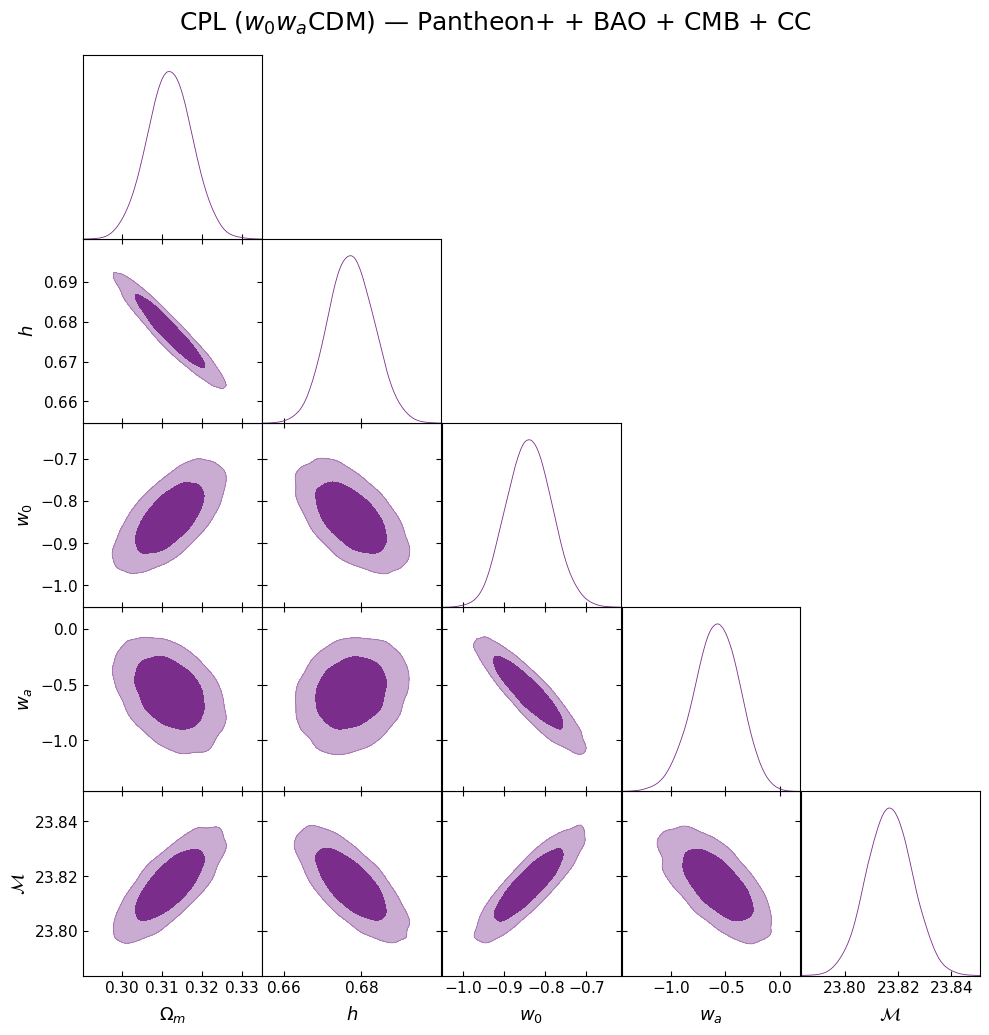

In [60]:
prior_cpl = Prior()
prior_cpl.add_parameter('om',   dist=(0.1, 0.5))
prior_cpl.add_parameter('h',    dist=(0.55, 0.85))
prior_cpl.add_parameter('obh2', dist=(0.02, 0.025))
prior_cpl.add_parameter('w0',   dist=(-3.0, 0.5))
prior_cpl.add_parameter('wa',   dist=(-5.0, 5.0))
prior_cpl.add_parameter('Mcal', dist=(23.0, 24.5))

def log_like_cpl_combined(params):
    om, h, obh2, w0, wa, Mcal = (
        params['om'], params['h'], params['obh2'],
        params['w0'], params['wa'], params['Mcal'])
    M_abs = Mcal - 5.0 * np.log10(cH0 / h) - 25.0
    chi2 = (chi2_snia_physical(M_abs, om, h, w0, wa)
            + chi2_bao_desi(om, obh2, h, w0, wa)
            + chi2_cmb(om, obh2, h, w0, wa)
            + chi2_cc(om, h, w0, wa)
            )
    return -0.5 * chi2

sampler_cpl = Sampler(prior_cpl, log_like_cpl_combined, n_live=1500)
sampler_cpl.run(verbose=True)

pts_cpl, lw_cpl, ll_cpl = sampler_cpl.posterior()
w_cpl = np.exp(lw_cpl - lw_cpl.max()); w_cpl /= w_cpl.sum()

res_cpl = print_results('CPL — Pantheon+ + DESI DR2 + CMB',
    pts_cpl, w_cpl,
    ['om','h','obh2','w0','wa','Mcal'],
    ['Ω_m','h','ω_b','w₀','w_a','M_cal'])

s_cpl = MCSamples(samples=pts_cpl, weights=w_cpl,
    names=['om','h','obh2','w0','wa','Mcal'],
    labels=[r'\Omega_m','h',r'\omega_b',r'w_0',r'w_a',r'\mathcal{M}'],
    settings={'smooth_scale_2D': 0.3, 'smooth_scale_1D': 0.3})

g = plots.get_subplot_plotter(width_inch=10)
g.settings.alpha_filled_add = 0.7
g.settings.axes_fontsize=14; g.settings.lab_fontsize=16
g.triangle_plot(s_cpl, ['om','h','w0','wa','Mcal'], filled=True, contour_colors=['#7B2D8B'])
plt.suptitle(r'CPL ($w_0 w_a$CDM) — Pantheon+ + BAO + CMB + CC', fontsize=18, y=1.03)
plt.savefig('CPL_PP_combined_corner.pdf', dpi=300, bbox_inches='tight')
plt.show()

**§5.1 (cont.)** SH0ES-anchored CPL.

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 40     | 1        | 4        | 66100    | N/A    | 13422 | -805.91  
CPL anchored: log Z = -805.91

══════════════════════════════════════════════════════════
  CPL Pantheon+ + calibrators (SH0ES-anchored)
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                  om     0.3025   +0.0051   -0.0051
                   h     0.6886   +0.0056   -0.0054
                obh2     0.0225   +0.0001   -0.0001
                  w0    -0.8620   +0.0554   -0.0546
                  wa    -0.6589   +0.2175   -0.2264
                Mcal    23.8114   +0.0084   -0.0085
──────────────────────────────────────────────────────────
Removed no burn in


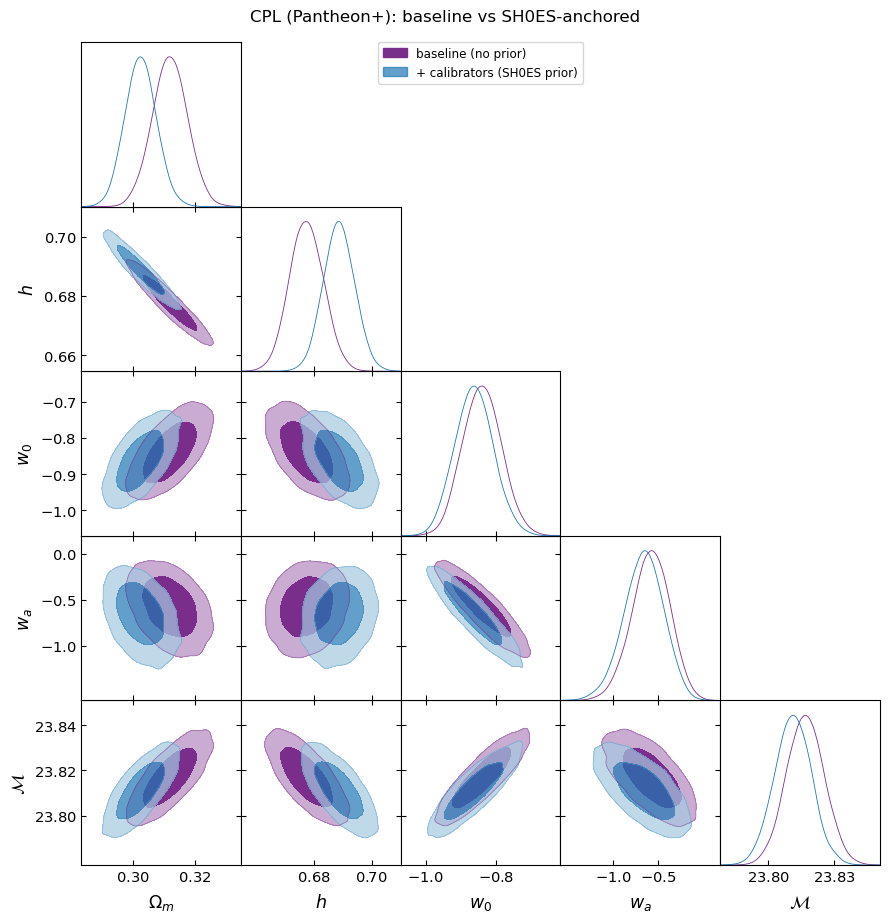

In [61]:
prior_cpl_anc = Prior()
prior_cpl_anc.add_parameter('om',   dist=(0.1, 0.5))
prior_cpl_anc.add_parameter('h',    dist=(0.55, 0.85))
prior_cpl_anc.add_parameter('obh2', dist=(0.02, 0.025))
prior_cpl_anc.add_parameter('w0', dist=(-3.0, 0.5))
prior_cpl_anc.add_parameter('wa', dist=(-5.0, 5.0))
prior_cpl_anc.add_parameter('Mcal', dist=(23.0, 24.5))
def ll_cpl_anc(p):
    om, h, obh2, Mcal = p['om'], p['h'], p['obh2'], p['Mcal']
    w0 = p['w0']
    wa = p['wa']
    M_abs = Mcal - 5.0*np.log10(cH0/h) - 25.0
    chi2 = (chi2_snia_physical(M_abs, om, h, w0, wa)
            + chi2_bao_desi(om, obh2, h, w0, wa)
            + chi2_cmb(om, obh2, h, w0, wa)
            + chi2_cc(om, h, w0, wa)
            + chi2_calibrators(M_abs))
    return -0.5*chi2
    
sampler_cpl_anc = Sampler(prior_cpl_anc, ll_cpl_anc, n_live=1500)
sampler_cpl_anc.run(verbose=True)
pts_cpl_anc, _lw, _ = sampler_cpl_anc.posterior()
w_cpl_anc = np.exp(_lw-_lw.max()); w_cpl_anc /= w_cpl_anc.sum()
print(f'CPL anchored: log Z = {sampler_cpl_anc.log_z:.2f}')
print_results('CPL Pantheon+ + calibrators (SH0ES-anchored)', pts_cpl_anc, w_cpl_anc, ['om','h','obh2','w0','wa','Mcal'], ['om','h','obh2','w0','wa','Mcal'])

s_cpl_anc = MCSamples(samples=pts_cpl_anc, weights=w_cpl_anc, names=['om','h','obh2','w0','wa','Mcal'], labels=[r'\Omega_m','h',r'\omega_b',r'w_0',r'w_a',r'\mathcal{M}'],
                      settings={'smooth_scale_2D': 0.3, 'smooth_scale_1D': 0.3})
g = plots.get_subplot_plotter(width_inch=9)
g.settings.alpha_filled_add = 0.7; g.settings.axes_fontsize=14; g.settings.lab_fontsize=16
g.triangle_plot([s_cpl, s_cpl_anc], ['om','h','w0','wa','Mcal'], filled=True,
                legend_labels=['baseline (no prior)', '+ calibrators (SH0ES prior)'],
                contour_colors=['#7B2D8B', '#1F77B4'], markers={'h': 0.7304})
plt.suptitle(r'CPL (Pantheon+): baseline vs SH0ES-anchored', y=1.02)
plt.savefig('CPL_anchored_contour.pdf', dpi=300, bbox_inches='tight'); plt.show()


## 5.2 DES-Dovekie


Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 55000    | N/A    | 12337 | -851.08  

══════════════════════════════════════════════════════════
  CPL — DES-Dovekie + DESI DR2 + CMB
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                 Ω_m     0.3133   +0.0055   -0.0053
                   h     0.6764   +0.0055   -0.0054
                 ω_b     0.0224   +0.0001   -0.0001
                  w₀    -0.8175   +0.0571   -0.0540
                 w_a    -0.6641   +0.2177   -0.2317
──────────────────────────────────────────────────────────
Removed no burn in


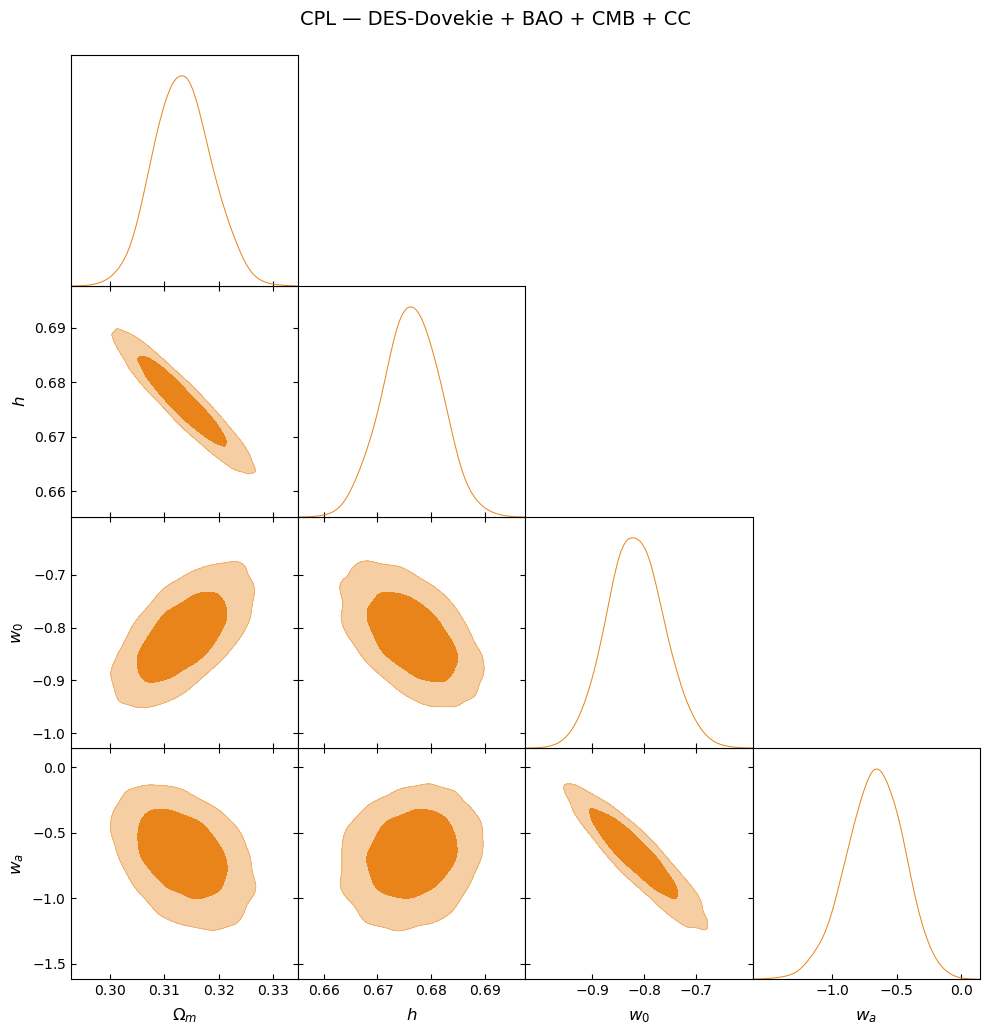

In [62]:
if DES_LOADED:
    prior_cpl_des = Prior()
    prior_cpl_des.add_parameter('om',   dist=(0.1, 0.5))
    prior_cpl_des.add_parameter('h',    dist=(0.55, 0.85))
    prior_cpl_des.add_parameter('obh2', dist=(0.02, 0.025))
    prior_cpl_des.add_parameter('w0',   dist=(-3.0, 0.5))
    prior_cpl_des.add_parameter('wa',   dist=(-5.0, 5.0))

    def log_like_cpl_des(params):
        om, h, obh2, w0, wa = (
            params['om'], params['h'], params['obh2'],
            params['w0'], params['wa'])
        chi2 = (chi2_des(om, h, w0, wa)
                + chi2_bao_desi(om, obh2, h, w0, wa)
                + chi2_cmb(om, obh2, h, w0, wa)
                + chi2_cc(om, h, w0, wa)
                )
        return -0.5 * chi2

    sampler_cpl_des = Sampler(prior_cpl_des, log_like_cpl_des, n_live=1500)
    sampler_cpl_des.run(verbose=True)
    pts_cpld, lw_cpld, ll_cpld = sampler_cpl_des.posterior()
    w_cpld = np.exp(lw_cpld - lw_cpld.max()); w_cpld /= w_cpld.sum()

    res_cpld = print_results('CPL — DES-Dovekie + DESI DR2 + CMB',
        pts_cpld, w_cpld,
        ['om','h','obh2','w0','wa'],
        ['Ω_m','h','ω_b','w₀','w_a'])

    s_cpld = MCSamples(samples=pts_cpld, weights=w_cpld,
        names=['om','h','obh2','w0','wa'],
        labels=[r'\Omega_m','h',r'\omega_b',r'w_0',r'w_a'],
        settings={'smooth_scale_2D': 0.3, 'smooth_scale_1D': 0.3})

    g = plots.get_subplot_plotter(width_inch=10)
    g.settings.alpha_filled_add = 0.7
    g.settings.axes_fontsize = 12
    g.settings.lab_fontsize = 14
    g.triangle_plot(s_cpld, ['om','h','w0','wa'],
                    filled=True, contour_colors=['#E8841A'])
    plt.suptitle(r'CPL — DES-Dovekie + BAO + CMB + CC', fontsize=14, y=1.03)
    plt.savefig('CPL_DES_combined_corner.pdf', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('DES-Dovekie not loaded.')

### 5.x  CPL: supernova-sample dependence in the (w0, wa) plane
Single overlay of the two EXISTING combined CPL posteriors (NO sampler re-run):
Pantheon+   -> s_cpl   (filled, light purple)
DES-Dovekie -> s_cpld  (thick dashed orange line contours)
Both are the getdist MCSamples already built in §5.1; we only re-plot them here.

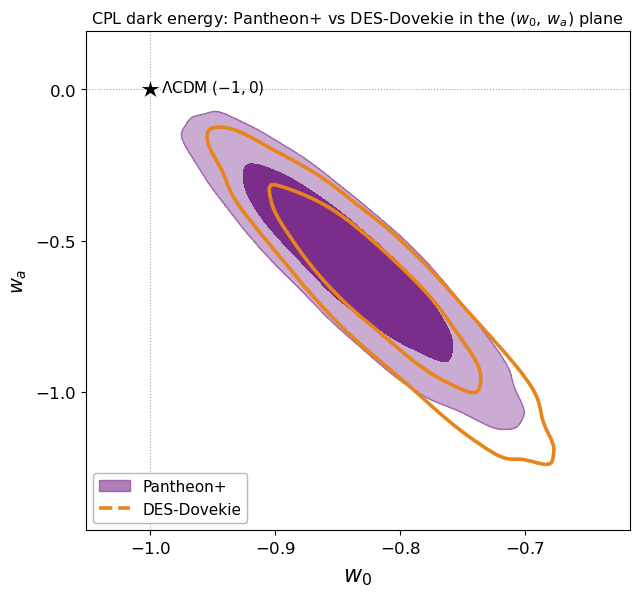

In [63]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

if DES_LOADED:
    g = plots.get_single_plotter(width_inch=6.5, ratio=0.9)
    g.settings.alpha_filled_add = 0.45 
    g.settings.axes_fontsize = 12
    g.settings.lab_fontsize = 14

    g.plot_2d(s_cpl, 'w0', 'wa', filled=True, colors=['#7B2D8B'])
    ax = g.subplots[0, 0]

    g.add_2d_contours(s_cpld, 'w0', 'wa', ax=ax, filled=False,
                      color='#E8841A', lw=2.6, ls='-')

    ax.plot(-1.0, 0.0, marker='*', ms=16, color='k', mec='white', mew=0.8, zorder=12)
    ax.annotate(r'$\Lambda$CDM $(-1,0)$', xy=(-1.0, 0.0), xytext=(8, -2),
                textcoords='offset points', fontsize=11, zorder=12)
    ax.axhline(0.0,  color='0.65', lw=0.8, ls=':', zorder=1)
    ax.axvline(-1.0, color='0.65', lw=0.8, ls=':', zorder=1)

    ax.set_xlabel(r'$w_0$', fontsize=16); ax.set_ylabel(r'$w_a$', fontsize=14)
    ax.legend(handles=[
        mpatches.Patch(facecolor='#7B2D8B', alpha=0.6, edgecolor='#7B2D8B', label='Pantheon+'),
        mlines.Line2D([], [], color='#E8841A', lw=2.6, ls='--', label='DES-Dovekie'),
    ], loc='lower left', fontsize=11, framealpha=0.92, facecolor='white', edgecolor='0.7')
    ax.set_title(r'CPL dark energy: Pantheon+ vs DES-Dovekie in the $(w_0,\,w_a)$ plane',
                 fontsize=11.5)

    g.export('CPL_w0wa_PP_vs_DES.pdf')
    plt.show()

---
## Export chains for reconstruction notebook

Saves the ΛCDM / wCDM / CPL posterior chains (Pantheon+ and DES-Dovekie) to `.npy` files consumed by `de_reconstruction_full.ipynb`. **Re-run this cell whenever the fits above change** (e.g. after the rd_GA patch) so the reconstruction always uses current chains. Λ_sCDM is intentionally NOT exported — it is excluded from reconstruction.

In [64]:
import numpy as _np

_chain_exports = [
    ('chains_LCDM_combined_PP',  pts_lcdm, lw_lcdm),
    ('chains_wCDM_combined_PP',  pts_wcdm, lw_wcdm),
    ('chains_CPL_combined_PP',   pts_cpl,  lw_cpl),
]
if DES_LOADED:
    _chain_exports += [
        ('chains_LCDM_combined_DES', pts_ld,  lw_ld),
        ('chains_wCDM_combined_DES', pts_wd,  lw_wd),
        ('chains_CPL_combined_DES',  pts_cpld, lw_cpld),
    ]
else:
    print('⚠ DES-Dovekie not loaded — DES chains NOT exported.')

for _name, _pts, _lw in _chain_exports:
    _np.save(f'{_name}_pts.npy',  _pts)
    _np.save(f'{_name}_logw.npy', _lw)
    print(f'saved {_name}_pts.npy  ({_pts.shape[0]:,} × {_pts.shape[1]})  +  _logw.npy')

print('\n✓ Chains exported. Reconstruction notebook can now be run.')


saved chains_LCDM_combined_PP_pts.npy  (49,700 × 4)  +  _logw.npy
saved chains_wCDM_combined_PP_pts.npy  (59,000 × 5)  +  _logw.npy
saved chains_CPL_combined_PP_pts.npy  (66,500 × 6)  +  _logw.npy
saved chains_LCDM_combined_DES_pts.npy  (38,600 × 3)  +  _logw.npy
saved chains_wCDM_combined_DES_pts.npy  (47,800 × 4)  +  _logw.npy
saved chains_CPL_combined_DES_pts.npy  (55,000 × 5)  +  _logw.npy

✓ Chains exported. Reconstruction notebook can now be run.


---
# 6. $\Lambda_s$CDM — Sign-switching Cosmological Constant

**Reference:** Akarsu et al. (2023), arXiv:2307.10086

## Physical motivation

$\Lambda$CDM has well-known tensions with observations: the $H_0$ tension
(Planck vs SH0ES, $\sim 5\sigma$), the $S_8$ tension, and hints of evolving
dark energy from DESI BAO. $\Lambda_s$CDM proposes that the cosmological
constant switches sign at a transition redshift $z_\dagger$, going from
$-|\Lambda|$ (AdS) at high $z$ to $+|\Lambda|$ (dS) at low $z$:

$$E^2(z) = \Omega_m(1+z)^3 + \Omega_r(1+z)^4 + \Omega_\Lambda \cdot \mathcal{S}(z)$$

where $\mathcal{S}(z) = +1$ for $z < z_\dagger$ and $\mathcal{S}(z) = -1$
for $z > z_\dagger$. Akarsu et al. report a preferred transition near
$z_\dagger \approx 1.7$ using Planck + BOSS BAO + Pantheon.

## Free parameters

$(\Omega_m, h, \omega_b, z_\dagger, \mathcal{M})$ — same as $\Lambda$CDM
plus the transition redshift $z_\dagger$. ($\mathcal{M}$ is dropped when
using DES-Dovekie, which marginalizes it analytically.)

## Main result of this section: $z_\dagger$ is not constrained from above

With our data combination (DESI DR2 + Pantheon+/DES + Planck compressed +
Cosmic Chronometers), the transition redshift $z_\dagger$ is **not
constrained from above**: the posterior leans to the upper prior boundary
and the profile likelihood flattens for $z_\dagger \gtrsim 2$.

**Physical reason — 3D (anisotropic) vs angular (transversal) BAO.**
The sign-flip modifies $H(z)$ for $z > z_\dagger$. DESI DR2 provides
anisotropic 3D BAO, including the radial observable
$D_H/r_d = c/[H(z)\, r_d]$, which probes $H(z)$ *directly* at
$z \simeq 0.5$–$2.3$ — exactly the range where the transition would act.
These tight radial constraints leave no room for an active sign-flip, so
$z_\dagger$ is pushed to high values where the mechanism is effectively
switched off and the model reduces to $\Lambda$CDM.

This contrasts with transversal (angular) BAO, which measures only
$D_M/r_d$ — an integral of $1/H(z)$ — and is far less sensitive to the
local shape of $H(z)$. Analyses anchored on transversal BAO therefore
retain a well-defined interior $z_\dagger$, whereas 3D BAO does not. The
constraint on $z_\dagger$ reported in earlier and transversal-BAO-based
works thus does not carry over to DESI DR2: the difference is driven by
the *type* of BAO data, not by the dataset epoch alone.

**Consequence for dark-energy reconstruction.** Because DESI DR2 leaves
$z_\dagger$ effectively unconstrained, a reconstructed dark-energy history
for $\Lambda_s$CDM would be arbitrary — any sufficiently high $z_\dagger$
yields essentially $\Lambda$CDM across the observable range. We therefore
do **not** perform a dark-energy reconstruction for this model; the
reconstruction chapter is restricted to models whose parameters DESI DR2
constrains meaningfully.

## Section outline

- **6.1** Fit with Pantheon+ + DESI DR2 + CMB + CC
- **6.2** Fit with DES-Dovekie + DESI DR2 + CMB + CC (robustness w.r.t. SnIa sample)
- **6.3** The transition redshift $z_\dagger$ is weakly bounded — profile likelihood
- **6.4** Is this a property of DESI DR2, or of 3D anisotropic BAO in general? — controlled comparison

Robustness checks (smooth-implementation stability and profile without DESI Ly$\alpha$) are collected in the Appendix at the end of the notebook.

## Implementation note

We use a smooth tanh transition with rapidity $\nu = 20$
($\Delta z_\text{transition} \approx 0.05$) instead of a hard sign switch,
to avoid numerical issues in the integration of $H(z)$ across $z_\dagger$.
The next cell defines the smooth versions of all cosmological observables.


In [65]:
NU = 20

# ── Smooth E² ──────────────────────────────────────────────────
def E2_scdm_smooth(z, om, h, zt, nu=NU):
    z = np.asarray(z, dtype=float)
    a = 1.0 / (1.0 + z)
    om_r = 4.18e-5 / h**2
    om_de = 1.0 - om - om_r
    sign_smooth = np.tanh(nu * (zt - z)) / np.tanh(nu * zt)
    return om * a**(-3) + om_r * a**(-4) + om_de * sign_smooth

def E_scdm_smooth(z, om, h, zt, nu=NU):
    return np.sqrt(np.maximum(E2_scdm_smooth(z, om, h, zt, nu), 1e-30))

def H_scdm_smooth(z, om, h, zt, nu=NU):
    return 100.0 * h * E_scdm_smooth(z, om, h, zt, nu)

# ── Smooth distances ───────────────────────────────────────────
def DL_array_scdm_smooth(z_arr, om, h, zt):
    z_arr = np.asarray(z_arr)
    z_max = z_arr.max() + 0.05
    z_grid = np.concatenate([
        [0.0],
        np.logspace(np.log10(1e-4), np.log10(z_max), N_GRID - 1)
    ])
    z_grid = np.unique(z_grid)
    inv_E = 1.0 / E_scdm_smooth(z_grid, om, h, zt)
    chi_grid = np.concatenate([[0.0], np.cumsum(
        0.5 * (inv_E[:-1] + inv_E[1:]) * np.diff(z_grid)
    )])
    chi = np.interp(z_arr, z_grid, chi_grid)
    return (cH0 / h) * (1.0 + z_arr) * chi

def D_M_scdm_smooth(z, om, h, zt):
    result, _ = quad(lambda zp: 1.0 / E_scdm_smooth(zp, om, h, zt), 0.0, float(z))
    return (cH0 / h) * result

def D_H_scdm_smooth(z, om, h, zt):
    return c / H_scdm_smooth(z, om, h, zt)

def D_V_scdm_smooth(z, om, h, zt):
    dm = D_M_scdm_smooth(z, om, h, zt)
    dh = D_H_scdm_smooth(z, om, h, zt)
    return (z * dm**2 * dh)**(1.0/3.0)

# ── Smooth r_s, R_shift, l_a ───────────────────────────────────
def r_s_scdm_smooth(ze_func, om, obh2, h, zt):
    z_epoch = ze_func(om, obh2, h)
    result, _ = quad(lambda z: c_s(z, obh2) / H_scdm_smooth(z, om, h, zt),
                     z_epoch, np.inf)
    return result

def R_shift_scdm_smooth(om, obh2, h, zt):
    z_star = z_cmb(om, obh2, h)
    return np.sqrt(om * (100*h)**2) * D_M_scdm_smooth(z_star, om, h, zt) / c

def l_a_scdm_smooth(om, obh2, h, zt):
    z_star = z_cmb(om, obh2, h)
    return np.pi * D_M_scdm_smooth(z_star, om, h, zt) / r_s_scdm_smooth(z_cmb, om, obh2, h, zt)

# ── Smooth chi2 ────────────────────────────────────────────────
def chi2_snia_smooth(M_abs, om, h, zt):
    DL = z_hel_corr * DL_array_scdm_smooth(z_HD, om, h, zt)
    delta = mb_corr - (M_abs + 5.0*np.log10(DL) + 25.0)
    return delta @ InvCovTotal @ delta

def chi2_bao_smooth(om, obh2, h, zt):
    rd = rd_GA(om, h, obh2)
    chi2 = 0.0
    for z_eff, dv_obs, sigma in desi_iso:
        chi2 += ((dv_obs - D_V_scdm_smooth(z_eff, om, h, zt) / rd) / sigma)**2
    for z_eff, dm_obs, sig_dm, dh_obs, sig_dh, r_corr in desi_aniso:
        dm_th = D_M_scdm_smooth(z_eff, om, h, zt) / rd
        dh_th = D_H_scdm_smooth(z_eff, om, h, zt) / rd
        cov = np.array([[sig_dm**2, r_corr*sig_dm*sig_dh],
                        [r_corr*sig_dm*sig_dh, sig_dh**2]])
        delta = np.array([dm_obs - dm_th, dh_obs - dh_th])
        chi2 += delta @ np.linalg.inv(cov) @ delta
    return chi2

def chi2_cmb_smooth(om, obh2, h, zt):
    theory = np.array([R_shift_scdm_smooth(om, obh2, h, zt),
                       l_a_scdm_smooth(om, obh2, h, zt),
                       obh2])
    v = theory - data_cmb
    return v @ invcov_cmb @ v

def chi2_cc_smooth(om, h, zt):
    H_th = 100.0 * h * E_scdm_smooth(z_cc, om, h, zt)
    delta = H_cc - H_th
    return delta @ InvCovCC @ delta

def chi2_des_smooth(om, h, zt):
    DL = DL_array_scdm_smooth(z_cmb_des, om, h, zt)
    mu_th = 5*np.log10((1+z_hel_des)/(1+z_cmb_des) * DL) + 25.0
    delta = mu_th - mu_obs_des
    chit2 = delta @ InvCovDES @ delta
    B     = np.sum(InvCovDES @ delta)
    C_sum = np.sum(InvCovDES)
    return chit2 - (B**2 / C_sum) + np.log(C_sum / (2*np.pi))


## 6.1 Fit — Pantheon+ + DESI DR2 + CMB + CC


Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 33     | 1        | 4        | 53500    | N/A    | 11514 | -761.27  

══════════════════════════════════════════════════════════
  LsCDM -- Pantheon+ + DESI DR2 + CMB + CC
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                  Om     0.3035   +0.0035   -0.0034
                   h     0.6892   +0.0029   -0.0029
                  ob     0.0224   +0.0001   -0.0001
                  zt     2.6747   +0.2165   -0.2169
                Mcal    23.7964   +0.0038   -0.0038
──────────────────────────────────────────────────────────
Removed no burn in


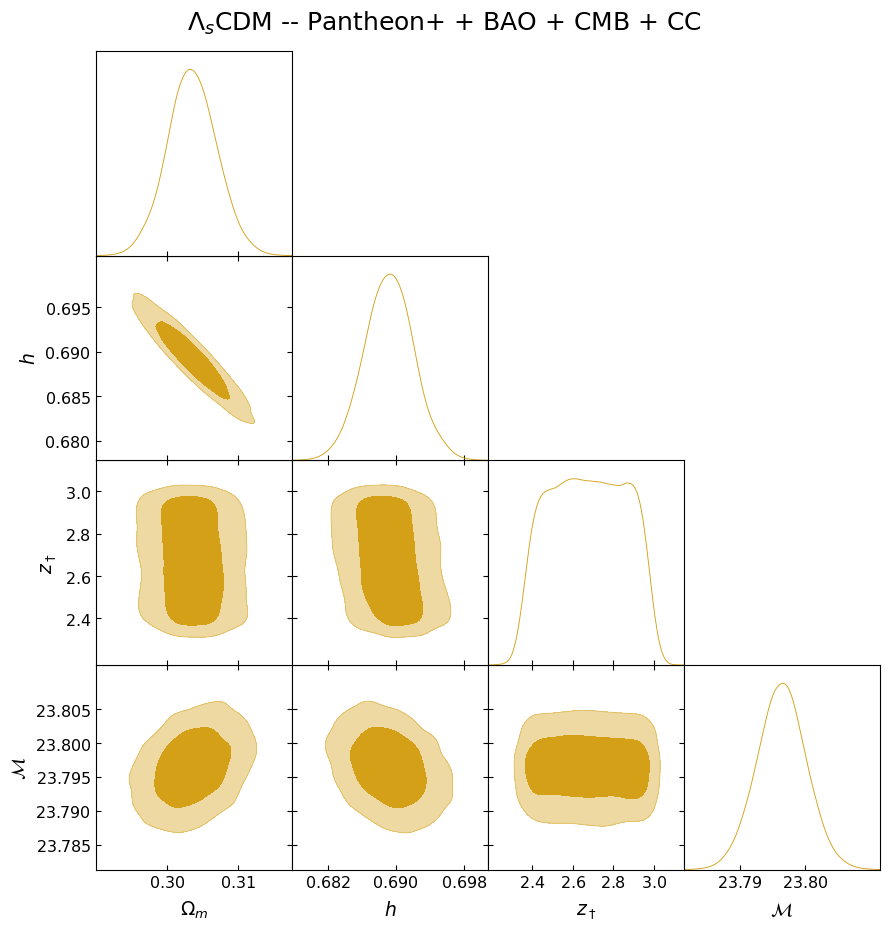

In [66]:
prior_scdm = Prior()
prior_scdm.add_parameter('om',   dist=(0.1, 0.5))
prior_scdm.add_parameter('h',    dist=(0.55, 0.85))
prior_scdm.add_parameter('obh2', dist=(0.02, 0.025))
prior_scdm.add_parameter('zt',   dist=(1.0, 3.0))
prior_scdm.add_parameter('Mcal', dist=(23.0, 24.5))

def log_like_scdm_smooth(params):
    om, h, obh2, zt, Mcal = (
        params['om'], params['h'], params['obh2'],
        params['zt'], params['Mcal'])
    z_test = np.linspace(0, 10.0, 300)
    if np.any(E2_scdm_smooth(z_test, om, h, zt) < 0):
        return -1e30
    M_abs = Mcal - 5.0*np.log10(cH0/h) - 25.0
    chi2 = (chi2_snia_smooth(M_abs, om, h, zt)
          + chi2_bao_smooth(om, obh2, h, zt)
          + chi2_cmb_smooth(om, obh2, h, zt)
          + chi2_cc_smooth(om, h, zt))
    return -0.5 * chi2

sampler_scdm = Sampler(prior_scdm, log_like_scdm_smooth, n_live=1500)
sampler_scdm.run(verbose=True)

pts_scdm, lw_scdm, ll_scdm = sampler_scdm.posterior()
w_scdm = np.exp(lw_scdm - lw_scdm.max()); w_scdm /= w_scdm.sum()

res_scdm = print_results(
    'LsCDM -- Pantheon+ + DESI DR2 + CMB + CC',
    pts_scdm, w_scdm,
    ['om', 'h', 'obh2', 'zt', 'Mcal'],
    ['Om', 'h', 'ob', 'zt', 'Mcal'])

s_scdm = MCSamples(
    samples=pts_scdm, weights=w_scdm,
    names=['om', 'h', 'obh2', 'zt', 'Mcal'],
    labels=[r'\Omega_m', 'h', r'\omega_b', r'z_\dagger', r'\mathcal{M}'],
    settings={'smooth_scale_2D': 0.3, 'smooth_scale_1D': 0.3})

g = plots.get_subplot_plotter(width_inch=9)
g.settings.alpha_filled_add = 0.7
g.settings.axes_fontsize=14
g.settings.lab_fontsize=16
g.triangle_plot(s_scdm, ['om', 'h', 'zt', 'Mcal'], filled=True,
                contour_colors=['#D4A017'])
plt.suptitle(r'$\Lambda_s$CDM -- Pantheon+ + BAO + CMB + CC',
             fontsize=18, y=1.03)
plt.savefig('LsCDM_smooth_corner.pdf', dpi=300, bbox_inches='tight')
plt.show()

**§6.1 (cont.)** SH0ES-anchored Λ_sCDM.

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 54300    | N/A    | 11634 | -800.81  
Lambda_sCDM anchored: log Z = -800.81

══════════════════════════════════════════════════════════
  Lambda_sCDM Pantheon+ + calibrators (SH0ES-anchored)
══════════════════════════════════════════════════════════
           Parameter     Median       +1σ       -1σ
──────────────────────────────────────────────────────────
                  Om     0.2996   +0.0034   -0.0034
                   h     0.6929   +0.0029   -0.0029
                  ob     0.0224   +0.0001   -0.0001
                  zt     2.5906   +0.2417   -0.1781
                Mcal    23.7971   +0.0039   -0.0038
──────────────────────────────────────────────────────────
Removed no burn in


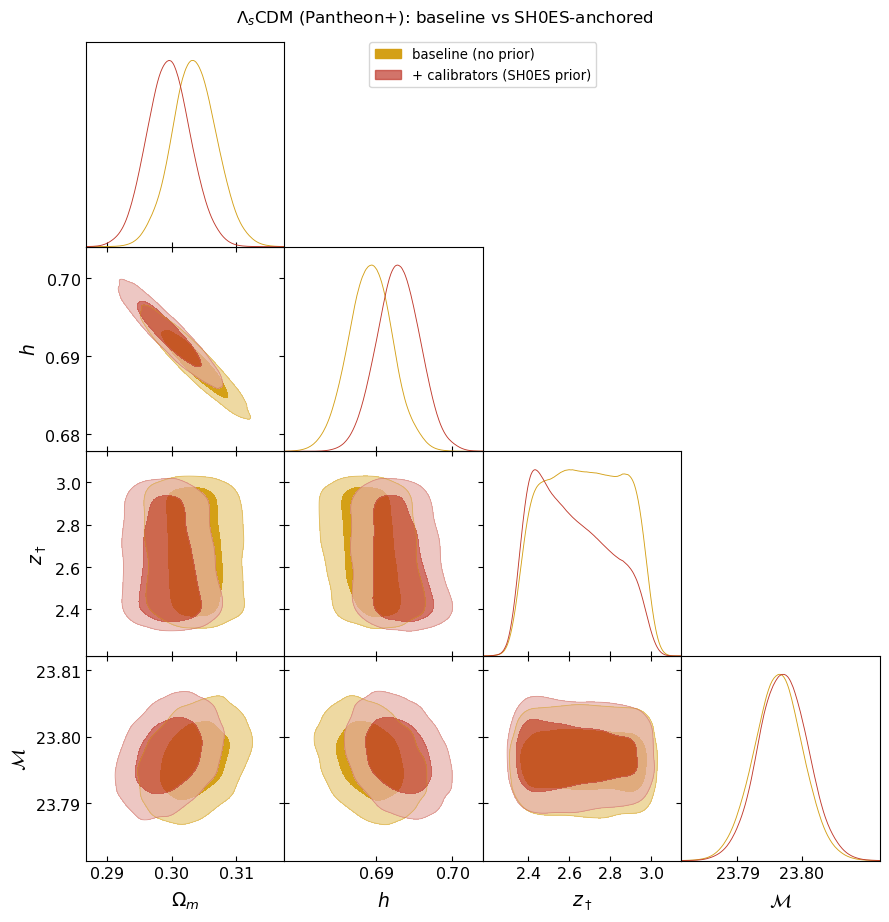

In [67]:
prior_scdm_anc = Prior()
prior_scdm_anc.add_parameter('om',   dist=(0.1, 0.5))
prior_scdm_anc.add_parameter('h',    dist=(0.55, 0.85))
prior_scdm_anc.add_parameter('obh2', dist=(0.02, 0.025))
prior_scdm_anc.add_parameter('zt',   dist=(1.0, 3.0))
prior_scdm_anc.add_parameter('Mcal', dist=(23.0, 24.5))
def ll_scdm_anc(p):
    om, h, obh2, zt, Mcal = p['om'], p['h'], p['obh2'], p['zt'], p['Mcal']
    if np.any(E2_scdm_smooth(np.linspace(0,10.0,300), om, h, zt) < 0):
        return -1e30
    M_abs = Mcal - 5.0*np.log10(cH0/h) - 25.0
    chi2 = (chi2_snia_smooth(M_abs, om, h, zt)
            + chi2_bao_smooth(om, obh2, h, zt)
            + chi2_cmb_smooth(om, obh2, h, zt)
            + chi2_cc_smooth(om, h, zt)
            + chi2_calibrators(M_abs))
    return -0.5*chi2
sampler_scdm_anc = Sampler(prior_scdm_anc, ll_scdm_anc, n_live=1500)
sampler_scdm_anc.run(verbose=True)
pts_scdm_anc, _lw, _ = sampler_scdm_anc.posterior()
w_scdm_anc = np.exp(_lw-_lw.max()); w_scdm_anc /= w_scdm_anc.sum()
print(f'Lambda_sCDM anchored: log Z = {sampler_scdm_anc.log_z:.2f}')
print_results('Lambda_sCDM Pantheon+ + calibrators (SH0ES-anchored)', pts_scdm_anc, w_scdm_anc,
              ['om','h','obh2','zt','Mcal'], ['Om','h','ob','zt','Mcal'])

s_scdm_anc = MCSamples(samples=pts_scdm_anc, weights=w_scdm_anc,
    names=['om','h','obh2','zt','Mcal'],
    labels=[r'\Omega_m','h',r'\omega_b',r'z_\dagger',r'\mathcal{M}'],
    settings={'smooth_scale_2D': 0.3, 'smooth_scale_1D': 0.3})
g = plots.get_subplot_plotter(width_inch=9)
g.settings.alpha_filled_add = 0.7; g.settings.axes_fontsize = 14; g.settings.lab_fontsize = 16
g.triangle_plot([s_scdm, s_scdm_anc], ['om','h','zt','Mcal'], filled=True,
                legend_labels=['baseline (no prior)', '+ calibrators (SH0ES prior)'],
                contour_colors=['#D4A017', '#C0392B'], markers={'h': 0.7304})
plt.suptitle(r'$\Lambda_s$CDM (Pantheon+): baseline vs SH0ES-anchored', y=1.02)
plt.savefig('LsCDM_anchored_contour.pdf', dpi=300, bbox_inches='tight'); plt.show()


## 6.2 Fit — DES-Dovekie + DESI DR2 + CMB + CC


In [ ]:
if DES_LOADED:
    prior_scdm_des = Prior()
    prior_scdm_des.add_parameter('om',   dist=(0.10, 0.50))
    prior_scdm_des.add_parameter('h',    dist=(0.55, 0.85))
    prior_scdm_des.add_parameter('obh2', dist=(0.020, 0.025))
    prior_scdm_des.add_parameter('zt',   dist=(1.0, 3.0))

    def log_like_scdm_des(params):
        om, h, obh2, zt = (params['om'], params['h'],
                           params['obh2'], params['zt'])
        z_test = np.linspace(0, 10.0, 300)
        if np.any(E2_scdm_smooth(z_test, om, h, zt) < 0):
            return -1e30
        chi2 = (chi2_des_smooth(om, h, zt)
              + chi2_bao_smooth(om, obh2, h, zt)
              + chi2_cmb_smooth(om, obh2, h, zt)
              + chi2_cc_smooth(om, h, zt))
        return -0.5 * chi2

    sampler_scdm_des = Sampler(prior_scdm_des, log_like_scdm_des, n_live=1500)
    sampler_scdm_des.run(verbose=True)
    pts_sd, lw_sd, ll_sd = sampler_scdm_des.posterior()
    w_sd = np.exp(lw_sd - lw_sd.max()); w_sd /= w_sd.sum()

    res_sd = print_results(
        'LsCDM -- DES-Dovekie + DESI DR2 + CMB + CC',
        pts_sd, w_sd,
        ['om', 'h', 'obh2', 'zt'],
        ['Om', 'h', 'ob', 'zt'])

    s_scdm_d = MCSamples(
        samples=pts_sd, weights=w_sd,
        names=['om', 'h', 'obh2', 'zt'],
        labels=[r'\Omega_m', 'h', r'\omega_b', r'z_\dagger'],
        settings={'smooth_scale_2D': 0.3, 'smooth_scale_1D': 0.3})

    g = plots.get_subplot_plotter(width_inch=9)
    g.settings.alpha_filled_add = 0.7
    g.settings.axes_fontsize = 14
    g.settings.lab_fontsize = 16
    g.triangle_plot(s_scdm_d, ['om', 'h', 'zt'], filled=True,
                    contour_colors=['#E8841A'])
    plt.suptitle(r'$\Lambda_s$CDM -- DES-Dovekie + BAO + CMB + CC',
                 fontsize=14, y=1.03)
    plt.savefig('LsCDM_DES_combined_corner.pdf', dpi=300,
                bbox_inches='tight')
    plt.show()

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Computing | 3      | 1        | 4        | 5900     | 1.0000 | 1     | -871.67  

## 6.3 The transition redshift $z_\dagger$ is weakly bounded — profile likelihood

The fits of §6.1–§6.2 give marginal posteriors for $z_\dagger$ that look broad and pushed against the upper prior boundary at $z_\dagger = 3$, suggesting the data offer no information on the transition redshift. That impression is misleading: the marginal posterior is a *volume-averaged* quantity, and in the compressed-CMB precision used here the volume in $(\Omega_m, h, \omega_b, M_\text{cal})$ at high $z_\dagger$ is comparatively large, dragging the marginal toward the upper wall. To see what the data actually say about $z_\dagger$, we examine the **profile likelihood**: at each fixed $z_\dagger$ we minimise the total $\chi^2$ over the remaining parameters.

The picture this produces is sharper than the marginal suggested. There is a clean **lower bound at $z_\dagger \simeq 2.3$**, set by the DESI Ly$\alpha$ BAO measurement at $z = 2.33$: the sign-switch must happen at or above that redshift, otherwise the radial BAO at $z = 2.33$ is being predicted by a model that has already flipped the dark-energy sign, which fits worse by $\Delta\chi^2 \simeq 30$ at $z_\dagger = 2$ and $\Delta\chi^2 \simeq 56$ at $z_\dagger = 1.5$. Above the Ly$\alpha$ threshold, however, the profile becomes very flat — the upper prior wall at $z_\dagger = 3$ is disfavoured by only $\Delta\chi^2 \approx 0.3$ (i.e. well below $1\sigma$). The model accommodates essentially any transition redshift in the upper half of the $[1, 3]$ prior box.

The physical interpretation is simple. The 3D anisotropic BAO observables ($D_M/r_d$ and $D_H/r_d$) directly pin down the expansion rate at the redshifts where they are measured. Once $z_\dagger$ moves above the highest-$z$ BAO point (here Ly$\alpha$ at $z = 2.33$), no observable lies inside the sign-flipped regime, and the model becomes effectively indistinguishable from $\Lambda$CDM at all measured redshifts. The data thus carry information about whether a sign switch happened *before* $z = 2.33$ — they reject that — but no information about *where* it might have happened beyond that.

**Consequence for the rest of the thesis.** Because there is no localised $z_\dagger$ — only a lower edge and a flat tail — the model has no unique best-fit transition point to feed into the dark-energy reconstruction of Chapter 7. This is the reason Λ$_s$CDM is excluded from the reconstruction analysis: not because it is disfavoured (it is, in fact, mildly preferred over $\Lambda$CDM, $\Delta\ln Z = +1.4$, see §8), but because the data do not determine its single new parameter.


In [ ]:
from scipy.optimize import minimize


def _chi2_scdm_total(om, h, obh2, zt, Mcal):
    z_test = np.linspace(0.001, 10.0, 200)
    if np.any(E2_scdm_smooth(z_test, om, h, zt) < 0):
        return 1e10
    M_abs = Mcal - 5.0 * np.log10(cH0 / h) - 25.0
    return (chi2_snia_smooth(M_abs, om, h, zt)
            + chi2_bao_smooth(om, obh2, h, zt)
            + chi2_cmb_smooth(om, obh2, h, zt)
            + chi2_cc_smooth(om, h, zt))


def _neg_ll_at_fixed_zt(params, zt_fixed):
    om, h, obh2, Mcal = params
    if not (0.10 < om   < 0.50 and
            0.55 < h    < 0.85 and
            0.020 < obh2 < 0.025 and
            23.0 < Mcal < 24.5):
        return 1e10
    return _chi2_scdm_total(om, h, obh2, zt_fixed, Mcal)


# Scan z† ────────────────────────────────────────────────────
zt_grid = np.linspace(0.5, 3.0, 26)
chi2_profile = np.zeros(len(zt_grid))
x0 = np.array([0.32, 0.67, 0.0222, 23.80])   # [Ωm, h, ωb, Mcal]

print('=' * 64)
print(f'{"z†":>6} | {"χ²_min":>10} | {"Ωm":>7} | {"h":>7} | '
      f'{"ωb":>7} | {"Mcal":>7}')
print('-' * 64)

for i, zt in enumerate(zt_grid):
    res = minimize(_neg_ll_at_fixed_zt, x0, args=(zt,),
                   method='Nelder-Mead',
                   options={'xatol': 1e-4, 'fatol': 1e-3,
                            'maxiter': 1500, 'adaptive': True})
    chi2_profile[i] = res.fun
    om, h, obh2, Mcal = res.x
    x0 = res.x   # warm start for next point
    print(f'{zt:>6.2f} | {res.fun:>10.3f} | {om:>7.4f} | {h:>7.4f} | '
          f'{obh2:>7.5f} | {Mcal:>7.4f}')

res_lcdm_limit = minimize(_neg_ll_at_fixed_zt, x0, args=(5000.0,),
                     method='Nelder-Mead',
                     options={'xatol': 1e-6, 'fatol': 1e-5,
                              'maxiter': 1500, 'adaptive': True})
chi2_lcdm = res_lcdm_limit.fun
chi2_profile_full = chi2_profile
chi2_lcdm_full    = chi2_lcdm

# Plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         gridspec_kw={'width_ratios': [1, 1]})
dchi2      = chi2_profile - chi2_profile.min()
dchi2_lcdm = chi2_lcdm    - chi2_profile.min()

# Left: full y-range
ax = axes[0]
ax.plot(zt_grid, dchi2, 'o-', color='#D4A017', lw=2, ms=6,
        label=r'Λ$_s$CDM profile')
ax.axhline(1.0, color='gray', ls=':',  alpha=0.7,
           label=r'$\Delta\chi^2 = 1$ (1σ)')
ax.axhline(4.0, color='gray', ls='--', alpha=0.7,
           label=r'$\Delta\chi^2 = 4$ (2σ)')
ax.axhline(dchi2_lcdm, color='#C0392B', ls='-.', alpha=0.8,
           label=fr'ΛCDM limit ($\Delta\chi^2$={dchi2_lcdm:+.2f})')
ax.set_xlabel(r'$z_\dagger$', fontsize=13)
ax.set_ylabel(r'$\Delta\chi^2$ (from best profile point)', fontsize=13)
ax.set_title('Full range', fontsize=12)
ax.legend(fontsize=10, loc='upper right')
ax.grid(alpha=0.3)

# Right: zoom on ΛCDM limit and confidence levels
ax = axes[1]
ax.plot(zt_grid, dchi2, 'o-', color='#D4A017', lw=2, ms=6,
        label=r'Λ$_s$CDM profile')
ax.axhline(1.0, color='gray', ls=':',  alpha=0.7,
           label=r'$\Delta\chi^2 = 1$ (1σ)')
ax.axhline(4.0, color='gray', ls='--', alpha=0.7,
           label=r'$\Delta\chi^2 = 4$ (2σ)')
ax.axhline(dchi2_lcdm, color='#C0392B', ls='-.', alpha=0.8,
           label=fr'ΛCDM limit ($\Delta\chi^2$={dchi2_lcdm:+.2f})')
ax.set_xlabel(r'$z_\dagger$', fontsize=13)
ax.set_ylabel(r'$\Delta\chi^2$', fontsize=13)
ax.set_title('Zoom on ΛCDM limit', fontsize=12)
ax.set_ylim(-15, 30)
ax.legend(fontsize=10, loc='upper right')
ax.grid(alpha=0.3)

plt.suptitle(r'Profile likelihood of $z_\dagger$ — Λ$_s$CDM',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('LsCDM_profile.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Numerical summary ─────────────────────────────────────────
zt_best   = zt_grid[np.argmin(chi2_profile)]
dchi2_min = chi2_profile.min() - chi2_lcdm

print()
print('=' * 64)
print('PROFILE LIKELIHOOD — RESULTS')
print('=' * 64)
print(f'  Grid best-fit z†                  : {zt_best:.3f}')
print(f'  χ²(Λ_sCDM @ profile minimum)     : '
      f'{chi2_profile.min():.3f}')
print(f'  χ²(ΛCDM equivalent, z† → ∞)      : {chi2_lcdm:.3f}')
print(f'  Δχ² (Λ_sCDM − ΛCDM)              : {dchi2_min:+.3f}')

# AIC / BIC — count the data points that actually enter the χ²
n_sne_fit = int(mask.sum())   # Pantheon+ SNe used for cosmology (calibrators excluded)
n_data = n_sne_fit + n_bao + n_cmb + n_cc   # SNe(cosmology) + BAO + CMB + CC
#        ^ defined just below; replaces the previous hardcoded 1701, which was
#          actually the *total* Pantheon+ catalogue size, not the fit-sample size.
k_lcdm  = 4     # Ωm, h, ωb, Mcal
k_lscdm = 5     # + z†
daic = dchi2_min + 2 * (k_lscdm - k_lcdm)
dbic = dchi2_min + (k_lscdm - k_lcdm) * np.log(n_data)
print(f'  ΔAIC                               : {daic:+.3f}')
print(f'  ΔBIC                               : {dbic:+.3f}')
print('=' * 64)

# ─── Verdict ────────────────────────────────────────────────────
# Quantify the lower edge and the upper-wall significance from the profile.
import math

# Δχ² at the upper prior wall (z† = 3.0)
dchi2_wall  = float(dchi2[-1])
sigma_wall  = math.sqrt(max(dchi2_wall, 0.0))

# Lower-edge disfavor: Δχ² at z† = 2.0 (just below the Lyα threshold at 2.33)
i_low = int(np.argmin(np.abs(zt_grid - 2.0)))
dchi2_low = float(dchi2[i_low])
sigma_low = math.sqrt(max(dchi2_low, 0.0))

print('\nINTERPRETATION:')
print(f'  • Profile minimum at z† = {zt_best:.2f},  Δχ²(Λ_sCDM−ΛCDM) = {dchi2_min:+.2f}')
print(f'  • Lower edge (z† = 2.0): Δχ² = {dchi2_low:+.2f}  '
      f'(~{sigma_low:.1f}σ disfavoured, set by Lyα BAO at z = 2.33)')
print(f'  • Upper prior wall (z† = 3.0): Δχ² = {dchi2_wall:+.2f}  '
      f'(~{sigma_wall:.1f}σ disfavoured)')

if dchi2_wall < 4.0:
    print('  • The profile is essentially flat above the Lyα threshold:')
    print('    the upper half of the z† prior is only weakly disfavoured.')
    print('    The data give a LOWER BOUND on z†, not a localised value.')
elif dchi2_wall < 9.0:
    print('  • The upper wall is moderately disfavoured but not excluded:')
    print('    z† is bounded below sharply, above only at the 2σ level.')
else:
    print('  • The upper wall is strongly disfavoured: z† is genuinely localised.')

print('  → Λ_sCDM is therefore reported as a lower bound on z†, not a measurement.')
print('    This is the reason the model is excluded from the dark-energy')
print('    reconstruction of Chapter 7 (no unique best-fit z† to anchor it).')


## 6.4 Does the choice of BAO compilation change the $z_\dagger$ constraint?

The profile likelihood of §6.3 shows a sharp lower edge near $z_\dagger \simeq 2.3$ — set by the DESI Ly$\alpha$ BAO measurement at $z = 2.33$ — and a nearly flat tail above it. Is the absence of an upper bound generic, or does it depend on the BAO data? We repeat the fit across a **two-by-two grid**: three BAO compilations (Akarsu BOSS+eBOSS 3D, DESI DR2 3D, transversal BAOtr), two SNIa calibrations (Pantheon+ and DES-Dovekie), and two $z_\dagger$ priors ($[1,3]$ baseline and $[1,5]$ wide). The wide prior is essential: a posterior pinned against a wall at $z_\dagger=3$ can hide whether the data actually bound $z_\dagger$ from above. The SNIa axis is a robustness check — if the $z_\dagger$ behaviour is driven by the BAO data, swapping Pantheon+ for the independently-calibrated DES-Dovekie sample should leave it essentially unchanged.

In the figure, rows are the SNIa calibration and columns are the prior range; colours denote the BAO compilation, and each legend entry reports the posterior mass in the main-peak window $[1.5, 2.6]$.

In [ ]:
# ================================================================
# §6.4 — z† marginal posterior: 3 BAO compilations × 2 SNIa × 2 priors
#        Λ_sCDM + CC + compressed CMB held fixed.
#        Rows = SNIa calibration (Pantheon+, DES-Dovekie)
#        Cols = z† prior range ([1,3] baseline, [1,5] wide)
# ================================================================
import pickle
from pathlib import Path
from scipy.stats import gaussian_kde

_iso_sources = ['akarsu', 'dr2', 'baotr']
_iso_labels = {
    'akarsu': 'Akarsu (BOSS+eBOSS, 3D)',
    'dr2':    'DESI DR2 (3D)',
    'baotr':  'BAOtr (transversal)',
}
_iso_colors = {'akarsu': '#3B6FB6', 'dr2': '#C0392B', 'baotr': '#2D8B46'}

_snia_rows  = [('PP', 'Pantheon+'), ('DES', 'DES-Dovekie')]
_prior_cols = [('',     3.0, r'$z_\dagger\in[1,3]$'),
               ('_zt5', 5.0, r'$z_\dagger\in[1,5]$')]

def _load(snia, suffix):
    chains = {}
    for bao in _iso_sources:
        fn = f'iso_v3_{bao}_{snia}_CC{suffix}.pkl'
        if not Path(fn).exists():
            continue
        with open(fn, 'rb') as f:
            d = pickle.load(f)
        pts = np.asarray(d['points']); w = np.asarray(d['weights'])
        chains[bao] = (pts[:, 3], w / w.sum())
    return chains

_rows_present = []
for snia, snia_lab in _snia_rows:
    if any(_load(snia, suf) for suf, _, _ in _prior_cols):
        _rows_present.append((snia, snia_lab))

if not _rows_present:
    print('No isolation chain files found.')
    print('Expected iso_v3_<bao>_PP_CC.pkl / _DES_CC.pkl (+ optional _zt5).')
    print('Run LsCDM_isolation_v3 (PP fits + DES fits §24, and wide-prior fits §25).')
else:
    peak_lo, peak_hi = 1.5, 2.6
    nrow, ncol = len(_rows_present), len(_prior_cols)
    fig, axes = plt.subplots(nrow, ncol, figsize=(7.0*ncol, 4.6*nrow),
                             sharex='col', sharey=False, squeeze=False)

    for r, (snia, snia_lab) in enumerate(_rows_present):
        for ci, (suffix, zt_max, col_lab) in enumerate(_prior_cols):
            ax = axes[r][ci]
            chains = _load(snia, suffix)
            zt_eval = np.linspace(1.0, zt_max, 500)
            if not chains:
                ax.text(0.5, 0.5, f'{col_lab} not yet run', transform=ax.transAxes,
                        ha='center', va='center', color='gray', fontsize=11)
            ymax = 0.0
            for bao, (zt_s, w) in chains.items():
                kde = gaussian_kde(zt_s, weights=w, bw_method=0.15)
                dens = kde(zt_eval)
                ymax = max(ymax, dens.max())
                frac = float(w[(zt_s >= peak_lo) & (zt_s <= peak_hi)].sum())
                ax.plot(zt_eval, dens, lw=2.3, color=_iso_colors[bao],
                        label=f'{_iso_labels[bao]} — {frac*100:.0f}% in [{peak_lo},{peak_hi}]')
                ax.fill_between(zt_eval, 0, dens, color=_iso_colors[bao], alpha=0.10)
            ax.axvline(2.33, color='gray', ls=':', alpha=0.7)
            ax.set_xlim(1.0, zt_max)
            ax.set_ylim(0, ymax*1.28 if ymax > 0 else 1)
            ax.grid(alpha=0.3)
            if chains:
                ax.legend(fontsize=8.5, loc='upper right', frameon=True, framealpha=0.93)
            if r == 0:
                ax.set_title(col_lab, fontsize=14)
            if ci == 0:
                ax.set_ylabel(f'{snia_lab}\n' + r'$P(z_\dagger\,|\,\mathrm{data})$', fontsize=11)
            if r == nrow-1:
                ax.set_xlabel(r'$z_\dagger$', fontsize=15)

    fig.suptitle(r'$z_\dagger$ marginal: 3 BAO compilations $\times$ 2 SNIa $\times$ 2 priors',
                 fontsize=14, y=1.0)
    plt.tight_layout()
    plt.savefig('LsCDM_bao_comparison.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    missing = []
    for snia, _ in _snia_rows:
        for suf, _, lab in _prior_cols:
            if not _load(snia, suf):
                missing.append(f'{snia}{suf or ""}')
    if missing:
        print('Panels still missing chains:', ', '.join(missing))



The grid tells a clearer story than any single panel. Reading **across the columns** (the $[1,3]\to[1,5]$ widening) separates the three BAO compilations into three genuinely different behaviours:

1. **BAOtr (transversal) localises low.** Its marginal peaks around $z_\dagger \simeq 1.6$–$1.9$ and keeps essentially all of its mass in $[1.5, 2.6]$ ($\sim$92% for Pantheon+, $\sim$99% for DES-Dovekie) under both priors — it is firmly bounded. Transversal BAO constrains the angular scale $\theta_\text{BAO}(z)\propto D_M(z)/r_d$ but not $D_H(z)/r_d$ separately; this is the same channel for which Akarsu et al. (2023) report $z_\dagger\simeq1.7$.

2. **Akarsu 3D (BOSS+eBOSS) localises high.** Its marginal peaks near $z_\dagger \simeq 2.25$–$2.3$, matching the published $z_\dagger = 2.44 \pm 0.29$. It remains well localised under the wide prior (peak fraction $\sim$94–98% with Pantheon+), though with the DES-Dovekie sample the wide-prior localisation loosens somewhat (to $\sim$71%), the only place the supernova choice materially weakens an upper edge.

3. **DESI DR2 (3D) does not localise.** Under the wide prior its mass leaks toward $z_\dagger = 5$: the peak fraction in $[1.5,2.6]$ drops from $\sim$58% to $\sim$34% (Pantheon+) and from $\sim$51% to $\sim$25% (DES-Dovekie). Counterintuitively, DR2's *tighter* radial measurement $D_H/r_d$ at $z=2.33$ pins $H(z)$ to $\Lambda$CDM there, so any $z_\dagger$ above that redshift fits almost equally well and no upper bound forms.

Reading **down the rows** (Pantheon+ vs DES-Dovekie) the qualitative picture is unchanged — each BAO compilation keeps its character (BAOtr low and bounded, Akarsu localised, DR2 diffuse) regardless of the SNIa calibration. The quantitative sensitivities are modest: the BAOtr peak shifts upward from $z_\dagger\simeq1.6$ (Pantheon+) to $\simeq1.9$ (DES-Dovekie) while staying fully bounded, and the Akarsu wide-prior localisation softens slightly under DES. Both stay in the regimes that distinguish them, so the three-way split is robust to the choice of supernova sample.

So the flat upper tail of §6.3 is **not** generic: it is specific to the DESI DR2 radial constraint. With the Akarsu 3D or transversal BAOtr data the model localises $z_\dagger$, and that qualitative three-way split holds under both supernova samples.

**For Bayesian model comparison** (§8) we keep $z_\dagger\in[1,3]$, matching Akarsu et al., so the $\Delta\ln Z$ values are comparable; the $[1,5]$ runs serve only the posterior-shape diagnostic above. Since the upper edge of $z_\dagger$ is data-unconstrained for compilations like DR2, a wider evidence prior would simply penalise $\Lambda_s$CDM through the Occam factor without being informed by data.

---
# 7. All-models comparison

The four models overlaid in the shared $(\Omega_m, h)$ plane,
separately for each SnIa sample.


In [ ]:
_cc = {'lcdm':'#2D8B46','wcdm':'#E8384F','cpl':'#3B6FB6','scdm':'#9B4FC9'}

#Pantheon+
sL = MCSamples(samples=pts_lcdm[:,:2], weights=w_lcdm, names=['om','h'],
    labels=[r'\Omega_m','h'], label=r'$\Lambda$CDM')
sW = MCSamples(samples=pts_wcdm[:,:2], weights=w_wcdm, names=['om','h'],
    labels=[r'\Omega_m','h'], label=r'$w$CDM')
sC = MCSamples(samples=pts_cpl[:,:2], weights=w_cpl, names=['om','h'],
    labels=[r'\Omega_m','h'], label='CPL')
sS = MCSamples(samples=pts_scdm[:,:2], weights=w_scdm, names=['om','h'],
    labels=[r'\Omega_m','h'], label=r'$\Lambda_s$CDM')

g = plots.get_subplot_plotter(width_inch=7, subplot_size=5.5)
g.settings.legend_fontsize = 13
g.settings.axes_fontsize = 14; g.settings.lab_fontsize = 16
g.settings.num_plot_contours = 2
g.settings.linewidth_contour = 2.2
g.triangle_plot([sL, sW, sC, sS], ['om','h'], filled=False,
    contour_colors=[_cc['lcdm'],_cc['wcdm'],_cc['cpl'],_cc['scdm']],
    contour_ls=['-','-','-','-'],
    contour_lws=[2.2,2.2,2.2,2.2],
    legend_labels=[r'$\Lambda$CDM', r'$w$CDM', 'CPL', r'$\Lambda_s$CDM'])

ax2d = g.subplots[1,0]

# 95% -> dashed + faint, 68% -> solid + full opacity (per model)
for cs in ax2d.collections:
    cs.set_linestyles(['--', '-'])     # [outer=95%, inner=68%]
    cs.set_alpha([0.35, 1.0])

# mean markers per model (WEIGHTED mean -- these are importance-weighted
# nested-sampling posteriors, not uniform samples, so plain .mean() is wrong)
for pts, wts, col in [(pts_lcdm,w_lcdm,_cc['lcdm']), (pts_wcdm,w_wcdm,_cc['wcdm']),
                       (pts_cpl,w_cpl,_cc['cpl']),   (pts_scdm,w_scdm,_cc['scdm'])]:
    mx = np.average(pts[:,0], weights=wts)
    my = np.average(pts[:,1], weights=wts)
    ax2d.plot(mx, my, marker='x', color=col, markersize=9, markeredgewidth=2.5, zorder=10)

# zoom to the region of overlap -- ADJUST these to your real cluster
ax2d.set_xlim(0.288, 0.332)
ax2d.set_ylim(0.660, 0.700)
g.subplots[0,0].set_xlim(0.288, 0.332)

plt.suptitle(r'All models — Pantheon+ + DESI DR2 + CMB + CC', fontsize=14, y=1.02)
plt.savefig('all_models_PP_om_h.pdf', dpi=300, bbox_inches='tight')
plt.show()

#DES-Dovekie
if DES_LOADED:
    sLd = MCSamples(samples=pts_ld[:,:2], weights=w_ld, names=['om','h'],
        labels=[r'\Omega_m','h'], label=r'$\Lambda$CDM')
    sWd = MCSamples(samples=pts_wd[:,:2], weights=w_wd, names=['om','h'],
        labels=[r'\Omega_m','h'], label=r'$w$CDM')
    sCd = MCSamples(samples=pts_cpld[:,:2], weights=w_cpld, names=['om','h'],
        labels=[r'\Omega_m','h'], label='CPL')
    sSd = MCSamples(samples=pts_sd[:,:2], weights=w_sd, names=['om','h'],
        labels=[r'\Omega_m','h'], label=r'$\Lambda_s$CDM')

    g = plots.get_subplot_plotter(width_inch=7, subplot_size=5.5)
    g.settings.legend_fontsize = 13
    g.settings.axes_fontsize = 14; g.settings.lab_fontsize = 16
    g.settings.num_plot_contours = 2
    g.settings.linewidth_contour = 2.2
    g.triangle_plot([sLd, sWd, sCd, sSd], ['om','h'], filled=False,
        contour_colors=[_cc['lcdm'],_cc['wcdm'],_cc['cpl'],_cc['scdm']],
        contour_ls=['-','-','-','-'],
        contour_lws=[2.2,2.2,2.2,2.2],
        legend_labels=[r'$\Lambda$CDM', r'$w$CDM', 'CPL', r'$\Lambda_s$CDM'])

    ax2d = g.subplots[1,0]

    # 95% -> dashed + faint, 68% -> solid + full opacity (per model)
    for cs in ax2d.collections:
        cs.set_linestyles(['--', '-'])
        cs.set_alpha([0.35, 1.0])

    for pts, wts, col in [(pts_ld,w_ld,_cc['lcdm']), (pts_wd,w_wd,_cc['wcdm']),
                          (pts_cpld,w_cpld,_cc['cpl']), (pts_sd,w_sd,_cc['scdm'])]:
        mx = np.average(pts[:,0], weights=wts)
        my = np.average(pts[:,1], weights=wts)
        ax2d.plot(mx, my, marker='x', color=col, markersize=9, markeredgewidth=2.5, zorder=10)

    # zoom to the region of overlap -- ADJUST these to your real DES cluster
    ax2d.set_xlim(0.288, 0.332)
    ax2d.set_ylim(0.660, 0.700)
    g.subplots[0,0].set_xlim(0.288, 0.332)

    plt.suptitle(r'All models — DES-Dovekie + DESI DR2 + CMB + CC', fontsize=14, y=1.02)
    plt.savefig('all_models_DES_om_h.pdf', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('DES-Dovekie not loaded — skipping DES comparison.')

### H₀ WHISKER (forest) PLOT — all models and data combinations
Pulls H0 = 100*h from each fit's stored result dict (res_*) and the anchored fits' weighted samples (pts_*_anc). No re-running.

In [ ]:
import matplotlib.pyplot as plt

def _h_from_res(res):
    """res[name]=(median,+σ,−σ) in h; return (H0, +err, −err)."""
    p50, ep, em = res['h']
    return 100*p50, 100*ep, 100*em

def _h_from_samples(pts, w, hcol=1):
    """weighted median + 16/84 of h from samples → (H0,+err,−err)."""
    w = w/ w.sum(); idx = np.argsort(pts[:, hcol]); cw = np.cumsum(w[idx])
    p16, p50, p84 = (pts[idx[np.searchsorted(cw, q)], hcol] for q in (0.16,0.50,0.84))
    return 100*p50, 100*(p84-p50), 100*(p50-p16)

# (label, getter) — built defensively so missing fits are skipped
rows = []
def _add(label, fn):
    try: rows.append((label, fn()))
    except Exception: pass

# Pantheon+ uncalibrated
_add('ΛCDM  (Pantheon+)',       lambda: _h_from_res(res_lcdm))
_add('wCDM  (Pantheon+)',       lambda: _h_from_res(res_wcdm))
_add('CPL   (Pantheon+)',       lambda: _h_from_res(res_cpl))
_add('Λ$_s$CDM  (Pantheon+)',   lambda: _h_from_res(res_scdm))
# Pantheon+ SH0ES-anchored (computed from samples; cols: om,h,obh2,...)
_add('ΛCDM  (Pantheon+, anchored)',     lambda: _h_from_samples(pts_lcdm_anc, w_lcdm_anc))
_add('wCDM  (Pantheon+, anchored)',     lambda: _h_from_samples(pts_wcdm_anc, w_wcdm_anc))
_add('CPL   (Pantheon+, anchored)',     lambda: _h_from_samples(pts_cpl_anc,  w_cpl_anc))
_add('Λ$_s$CDM  (Pantheon+, anchored)', lambda: _h_from_samples(pts_scdm_anc, w_scdm_anc))
# DES-Dovekie
_add('ΛCDM  (DES-Dovekie)',     lambda: _h_from_res(res_ld))
_add('wCDM  (DES-Dovekie)',     lambda: _h_from_res(res_wd))
_add('CPL   (DES-Dovekie)',     lambda: _h_from_res(res_cpld))
_add('Λ$_s$CDM  (DES-Dovekie)', lambda: _h_from_res(res_sd))

# ── Fallback / consistency guard: FINAL thesis values (Table 5.7). ──
FINAL_H0 = {
 'ΛCDM  (Pantheon+)': (68.54,0.28,0.28), 'wCDM  (Pantheon+)': (68.10,0.58,0.58),
 'CPL   (Pantheon+)': (67.72,0.59,0.59), 'Λ$_s$CDM  (Pantheon+)': (68.92,0.29,0.29),
 'ΛCDM  (Pantheon+, anchored)': (68.89,0.27,0.27), 'wCDM  (Pantheon+, anchored)': (69.28,0.54,0.54),
 'CPL   (Pantheon+, anchored)': (68.87,0.55,0.55), 'Λ$_s$CDM  (Pantheon+, anchored)': (69.29,0.28,0.28),
 'ΛCDM  (DES-Dovekie)': (68.51,0.27,0.27), 'wCDM  (DES-Dovekie)': (68.02,0.53,0.53),
 'CPL   (DES-Dovekie)': (67.64,0.54,0.54), 'Λ$_s$CDM  (DES-Dovekie)': (68.90,0.29,0.29),
}
if not rows:
    rows = list(FINAL_H0.items())
    print('NOTE: no live fits in memory — using FINAL (thesis Table 5.7) values.')
else:
    for lbl, (H0, ep, em) in rows:
        if lbl in FINAL_H0 and abs(H0 - FINAL_H0[lbl][0]) > 0.005:
            print(f'WARNING: {lbl}: live {H0:.2f} != final {FINAL_H0[lbl][0]:.2f} — stale run?')

# colour by model family
def _col(lbl):
    if 'Λ$_s$CDM' in lbl: return '#C0392B'
    if 'CPL'  in lbl:     return '#2D8B46'
    if 'wCDM' in lbl:     return '#E08E0B'
    return '#3B6FB6'   # ΛCDM

fig, ax = plt.subplots(figsize=(8.5, 0.45*len(rows)+1.5))
ys = np.arange(len(rows))[::-1]
for y, (lbl, (H0, ep, em)) in zip(ys, rows):
    ax.errorbar(H0, y, xerr=[[em],[ep]], fmt='o', color=_col(lbl),
                capsize=3, markersize=6, lw=1.8)
    ax.annotate(f'{H0:.2f}', (H0, y), textcoords='offset points',
                xytext=(0, 7), ha='center', fontsize=7.5, color='#333')

ax.axvspan(73.04-1.04, 73.04+1.04, color='#C0392B', alpha=0.08)
ax.axvline(73.04, color='#C0392B', ls='--', lw=1.2, alpha=0.7, label='SH0ES 73.04±1.04')
ax.axvspan(69.96-1.53, 69.96+1.53, color='#6C6C6C', alpha=0.10)
ax.axvline(69.96, color='#6C6C6C', ls='--', lw=1.2, alpha=0.8, label='CCHP 69.96±1.53')
ax.axvspan(67.36-0.54, 67.36+0.54, color='#3B6FB6', alpha=0.08)
ax.axvline(67.36, color='#3B6FB6', ls='--', lw=1.2, alpha=0.7, label='Planck 67.36±0.54')

ax.set_yticks(ys); ax.set_yticklabels([r[0] for r in rows], fontsize=9)
ax.set_xlabel(r'$H_0$  [km s$^{-1}$ Mpc$^{-1}$]', fontsize=12)
ax.set_title(r'$H_0$ across models, datasets, and SNIa calibration', fontsize=12)
ax.legend(fontsize=8.5, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('H0_whisker.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f'Plotted {len(rows)} fits. Note: all CMB+BAO fits sit near the Planck (early)')
print('value ~68-69; only the calibrator-only A.3 cross-check reaches the SH0ES band.')

---
# 8. Full Bayesian Evidence: ΛCDM vs wCDM vs CPL vs Λ$_s$CDM

We compare the four models through their Bayesian evidence
$\ln Z$, computed with the Nautilus importance-nested-sampling sampler.

**Sign convention.** Throughout this section,
$$\Delta \ln Z \equiv \ln Z(\text{model}) - \ln Z(\Lambda\text{CDM}),$$
so a **positive** $\Delta \ln Z$ favours the extended model over $\Lambda$CDM.
(Note: this is the opposite sign to the convention used by Akarsu et al.,
where positive values favour $\Lambda$CDM. Care is needed when comparing
numbers directly.)

**Uncertainty.** Each $\ln Z$ is the mean over $N_\text{seeds}=5$
independent runs with different random seeds; the quoted error is the
sample standard deviation, capturing run-to-run scatter of the evidence
integral.

**Prior dependence (important caveat).** Bayesian evidence penalises a
model by the prior volume of its extra parameters (the Occam factor).
The extension parameters here have priors of different widths:
$w_0 \in (-2.5, 0)$ for $w$CDM; $w_0 \in (-3, 0.5),\ w_a \in (-5, 5)$ for
CPL; and $z_\dagger \in (1, 3)$ for $\Lambda_s$CDM. CPL therefore carries
the largest Occam penalty, partly by virtue of its wide $w_a$ prior. The
$\Delta \ln Z$ values below are thus prior-dependent, as is generic for
Bayesian model comparison; they should be read together with the
parameter posteriors, not in isolation. The $\Lambda_s$CDM prior on
$z_\dagger$ matches that used in the isolation and triangle-plot analyses,
ensuring internal consistency across this work.


In [ ]:
# ================================================================
# BAYESIAN MODEL COMPARISON — multi-seed evidence + AIC/BIC
# ----------------------------------------------------------------
# Nautilus 1.0.x exposes only log_z (no built-in log_z_err). To obtain
# a robust uncertainty we re-run each model N_SEEDS times with different
# random seeds and report the mean and sample standard deviation of
# log Z. We also record the best-fit log-likelihood across all seeds to
# form the information criteria:
#     AIC = chi2_min + 2k        (k = number of free parameters)
#     BIC = chi2_min + k*ln(N)   (N = number of data points)
# Unlike the evidence, AIC/BIC are prior-independent and use only the
# best fit; they are reported as a cross-check on the Bayesian ranking.
#
# NOTE on k: the Pantheon+ fits sample M_B explicitly, so k includes it.
# The DES-Dovekie fits marginalise the SN offset analytically inside
# chi2_des, so each DES model has one fewer sampled parameter. This shifts
# every DES model's k by -1 uniformly, which CANCELS in ΔAIC/ΔBIC (the
# differences are unchanged); it would only matter for absolute AIC/BIC.
# ================================================================
N_SEEDS = 5
N_LIVE_EV = 1500

K_PARAMS     = {'ΛCDM': 4, 'wCDM': 5, 'CPL': 6, 'Λ_sCDM': 5}  # Pantheon+
K_PARAMS_DES = {'ΛCDM': 3, 'wCDM': 4, 'CPL': 5, 'Λ_sCDM': 4}  # DES

#count data points N for the combined likelihood
_n_sn_pp  = len(z_HD)
_n_sn_des = len(z_cmb_des)
_n_cc     = len(z_cc)
_N_CMB    = 3
_N_BAO    = 2*len(desi_aniso) + 1

def _total_N(n_sn):
    parts = [n_sn or 0, _N_BAO, _N_CMB, _n_cc or 0]
    return int(sum(parts)), parts

N_PP,  parts_pp  = _total_N(_n_sn_pp)
N_DES, parts_des = _total_N(_n_sn_des)
print(f'Data counts → Pantheon+: SNe={_n_sn_pp}, BAO={_N_BAO}, CMB={_N_CMB}, CC={_n_cc}  ⇒ N={N_PP}')
print(f'Data counts → DES      : SNe={_n_sn_des}, BAO={_N_BAO}, CMB={_N_CMB}, CC={_n_cc}  ⇒ N={N_DES}')
print(f'Free params k (Pantheon+): {K_PARAMS}')
print(f'Free params k (DES):       {K_PARAMS_DES}   (M_B marginalised, so −1 vs Pantheon+)\n')

def evidence_multiseed(prior, loglike, label=''):
    logzs, best_ll = [], -np.inf
    for sd in range(N_SEEDS):
        s = Sampler(prior, loglike, n_live=N_LIVE_EV, seed=sd)
        s.run(verbose=False)
        logzs.append(float(s.log_z))
        _, _, ll = s.posterior()
        best_ll = max(best_ll, float(np.max(ll)))
    arr = np.array(logzs)
    chi2_min = -2.0 * best_ll
    print(f'    {label:<10s} seeds: ' +
          ' '.join(f'{z:.2f}' for z in arr) +
          f'   → {arr.mean():.2f} ± {arr.std(ddof=1):.2f}   χ²min={chi2_min:.1f}')
    return arr.mean(), arr.std(ddof=1), chi2_min, arr

def _delta(a, da, ref, dref):
    return a - ref, float(np.hypot(da, dref))

def _aic_bic(chi2_min, k, N):
    return chi2_min + 2*k, chi2_min + k*np.log(N)

def _report(title, N, rows, kparams):
    ref_name, mZ_ref, sZ_ref, c2_ref = rows[0]
    aic_ref, bic_ref = _aic_bic(c2_ref, kparams[ref_name], N)
    print('\n' + '═' * 78)
    print(f'  {title}')
    print(f'  Mean ± std over {N_SEEDS} seeds, n_live = {N_LIVE_EV}, N_data = {N}')
    print('═' * 78)
    print(f'  {"Model":>8s}  {"ln Z":>14s}  {"Δln Z":>12s}  {"ΔAIC":>8s}  {"ΔBIC":>8s}')
    print('─' * 78)
    print(f'  {ref_name:>8s}  {mZ_ref:8.2f} ± {sZ_ref:.2f}  {"(ref)":>12s}  {0.0:8.2f}  {0.0:8.2f}')
    for name, mz, sz, c2 in rows[1:]:
        d, dd = _delta(mz, sz, mZ_ref, sZ_ref)
        aic, bic = _aic_bic(c2, kparams[name], N)
        print(f'  {name:>8s}  {mz:8.2f} ± {sz:.2f}  {d:+7.2f}±{dd:.2f}  '
              f'{aic-aic_ref:+8.2f}  {bic-bic_ref:+8.2f}')
    print('─' * 78)
    print('  Δln Z > 0 favours that model (more probable); ΔAIC/ΔBIC < 0 favours it')
    print('  (lower AIC/BIC = better). Jeffreys/Trotta: |Δln Z| ≈1 weak, ≈2.5 moderate, ≈5 strong.')

# ── Pantheon+ models ────────────────────────────────────────────
print('Running multi-seed evidence (Pantheon+) — N_SEEDS =', N_SEEDS)
rZ_lcdm = evidence_multiseed(prior_lcdm, log_like_lcdm_combined, 'ΛCDM')
rZ_wcdm = evidence_multiseed(prior_wcdm, log_like_wcdm_combined, 'wCDM')
rZ_cpl  = evidence_multiseed(prior_cpl,  log_like_cpl_combined,  'CPL')
rZ_scdm = evidence_multiseed(prior_scdm, log_like_scdm_smooth,   'Λ_sCDM')
_report('Bayesian Evidence + IC (Pantheon+ + DESI DR2 + CMB + CC)', N_PP,
        [('ΛCDM', *rZ_lcdm[:3]), ('wCDM', *rZ_wcdm[:3]),
         ('CPL', *rZ_cpl[:3]),   ('Λ_sCDM', *rZ_scdm[:3])], K_PARAMS)

# ── DES-Dovekie models ──────────────────────────────────────────
if DES_LOADED:
    print('\nRunning multi-seed evidence (DES-Dovekie) — N_SEEDS =', N_SEEDS)
    rZ_ld = evidence_multiseed(prior_lcdm_des, log_like_lcdm_des, 'ΛCDM')
    rZ_wd = evidence_multiseed(prior_wcdm_des, log_like_wcdm_des, 'wCDM')
    rZ_cd = evidence_multiseed(prior_cpl_des,  log_like_cpl_des,  'CPL')
    rZ_sd = evidence_multiseed(prior_scdm_des, log_like_scdm_des, 'Λ_sCDM')
    _report('Bayesian Evidence + IC (DES-Dovekie + DESI DR2 + CMB + CC)', N_DES,
            [('ΛCDM', *rZ_ld[:3]), ('wCDM', *rZ_wd[:3]),
             ('CPL', *rZ_cd[:3]),  ('Λ_sCDM', *rZ_sd[:3])], K_PARAMS_DES)

**Comparing the three criteria.** Bayesian evidence, AIC, and BIC weight the
parameter penalty differently, and reading them together is more informative than
any one alone (values below are consistent across both SNIa samples):

- **$\Lambda_s$CDM** is favoured by the evidence ($\Delta\ln Z\simeq+1.4$, moderate
  on the Jeffreys scale) and by AIC ($\Delta\mathrm{AIC}\simeq-3.1$), but **disfavoured
  by BIC** ($\Delta\mathrm{BIC}\simeq+2.4$). With $N\simeq1700$ the BIC penalty per
  extra parameter is $\ln N\simeq7.4$, which outweighs the $\sim$5 improvement in
  $\chi^2_{\min}$; AIC's flat $+2$ penalty does not. The support for the single extra
  $z_\dagger$ parameter is therefore real but moderate, and criterion-dependent.

- **CPL** shows the opposite tension sharply: it has the lowest $\chi^2_{\min}$ of all
  models (so AIC strongly favours it, $\Delta\mathrm{AIC}\simeq-5$ to $-7$), yet both
  the evidence ($\Delta\ln Z<0$) and BIC ($\Delta\mathrm{BIC}>0$) disfavour it. This is
  the classic signature of mild over-fitting: two extra parameters ($w_0,w_a$) buy a
  better fit, but not enough to justify themselves once the parameter volume is
  penalised properly.

- **wCDM** is disfavoured by every criterion (it neither fits better nor is simpler),
  and is the weakest of the four.

The overall picture is consistent across Pantheon+ and DES-Dovekie: $\Lambda_s$CDM is
the only extension with positive Bayesian evidence over $\Lambda$CDM, but the support
is moderate and does not survive the stricter BIC penalty — a more measured conclusion
than the evidence alone would suggest.

---

# Appendix — Λ$_s$CDM robustness checks

Supplementary diagnostics for the Λ$_s$CDM analysis. None of the results below enter the main narrative; they are kept for reviewer-traceable robustness.

- **A.1** Stability of the smooth implementation w.r.t. the transition rapidity $\nu$.
- **A.2** Profile likelihood on $z_\dagger$ with DESI Ly$\alpha$ removed — checks that the lack of an upper bound on $z_\dagger$ does not come from a single high-$z$ measurement.


## A.1 Stability w.r.t. the transition rapidity $\nu$


In [ ]:
# global NU so we probe the underlying observables directly.
om_t, h_t, zt_t = 0.30, 0.69, 1.7

def _DM_nu(z, nu):
    val, _ = quad(lambda zp: 1.0 / E_scdm_smooth(zp, om_t, h_t, zt_t, nu=nu),
                  0.0, z)
    return (cH0 / h_t) * val

print(f'{"ν":>5} | {"D_M(z=0.5)":>12} | {"D_M(z=1.0)":>12} | '
      f'{"D_M(z=2.0)":>12} | {"H(z=1.0)":>10} | {"H(z=1.7)":>10}')
print('-' * 78)
rows = {}
for nu_test in [10, 20, 50]:
    dm05 = _DM_nu(0.5, nu_test)
    dm10 = _DM_nu(1.0, nu_test)
    dm20 = _DM_nu(2.0, nu_test)
    h10  = H_scdm_smooth(1.0, om_t, h_t, zt_t, nu=nu_test)
    h17  = H_scdm_smooth(1.7, om_t, h_t, zt_t, nu=nu_test)
    rows[nu_test] = np.array([dm05, dm10, dm20, h10, h17])
    print(f'{nu_test:>5} | {dm05:>12.3f} | {dm10:>12.3f} | '
          f'{dm20:>12.3f} | {h10:>10.3f} | {h17:>10.3f}')
print('-' * 78)

stack = np.vstack([rows[10], rows[20], rows[50]])
rel = (stack.max(0) - stack.min(0)) / stack.mean(0) * 100
labels = ['D_M(0.5)', 'D_M(1.0)', 'D_M(2.0)', 'H(1.0)', 'H(1.7)']
print('Relative spread across ν ∈ {10,20,50}:')
for lab, r in zip(labels, rel):
    print(f'  {lab:<10s}: {r:.3f}%')

max_rel = rel.max()
if max_rel < 0.5:
    print(f'\n✓ All integrated observables vary by < 0.5% across ν '
          f'(max {max_rel:.3f}%).')
    print('  The analysis is effectively independent of the transition')
    print('  rapidity; ν = 20 is a safe default.')
else:
    print(f'\n⚠ Spread up to {max_rel:.2f}% — consider a sharper transition.')


## A.2 Profile likelihood — without DESI Ly$\alpha$


In [ ]:
desi_aniso_no_lya = [
    (0.510, 13.587, 0.169, 21.863, 0.427, -0.475),  # LRG1
    (0.706, 17.347, 0.180, 19.458, 0.332, -0.423),  # LRG2
    (0.934, 21.574, 0.153, 17.641, 0.193, -0.425),  # LRG3+ELG1
    (1.321, 27.605, 0.320, 14.178, 0.217, -0.437),  # ELG2
    (1.484, 30.519, 0.758, 12.816, 0.513, -0.489),  # QSO
    # Lyα at z=2.33 REMOVED
]


def chi2_bao_smooth_noLya(om, obh2, h, zt):
    rd = rd_GA(om, h, obh2)
    chi2 = 0.0
    for z_eff, dv_obs, sigma in desi_iso:
        chi2 += ((dv_obs - D_V_scdm_smooth(z_eff, om, h, zt) / rd)
                 / sigma) ** 2
    for z_eff, dm_obs, sig_dm, dh_obs, sig_dh, r_corr in desi_aniso_no_lya:
        dm_th = D_M_scdm_smooth(z_eff, om, h, zt) / rd
        dh_th = D_H_scdm_smooth(z_eff, om, h, zt) / rd
        cov = np.array([[sig_dm ** 2,           r_corr * sig_dm * sig_dh],
                        [r_corr * sig_dm * sig_dh, sig_dh ** 2]])
        delta = np.array([dm_obs - dm_th, dh_obs - dh_th])
        chi2 += delta @ np.linalg.inv(cov) @ delta
    return chi2


def _chi2_scdm_noLya(om, h, obh2, zt, Mcal):
    z_test = np.linspace(0.001, 10.0, 200)
    if np.any(E2_scdm_smooth(z_test, om, h, zt) < 0):
        return 1e10
    M_abs = Mcal - 5.0 * np.log10(cH0 / h) - 25.0
    return (chi2_snia_smooth(M_abs, om, h, zt)
            + chi2_bao_smooth_noLya(om, obh2, h, zt)
            + chi2_cmb_smooth(om, obh2, h, zt)
            + chi2_cc_smooth(om, h, zt))


def _neg_ll_noLya(params, zt_fixed):
    om, h, obh2, Mcal = params
    if not (0.10 < om   < 0.50 and
            0.55 < h    < 0.85 and
            0.020 < obh2 < 0.025 and
            23.0 < Mcal < 24.5):
        return 1e10
    return _chi2_scdm_noLya(om, h, obh2, zt_fixed, Mcal)


# Scan z† without Lyα ────────────────────────────────────────
chi2_profile_noLya = np.zeros(len(zt_grid))
x0 = np.array([0.32, 0.67, 0.0222, 23.80])

print('=' * 64)
print(f'{"z†":>6} | {"χ²_min":>10} | {"Ωm":>7} | {"h":>7} | '
      f'{"ωb":>7} | {"Mcal":>7}')
print('-' * 64)

for i, zt in enumerate(zt_grid):
    res = minimize(_neg_ll_noLya, x0, args=(zt,),
                   method='Nelder-Mead',
                   options={'xatol': 1e-5, 'fatol': 1e-4,
                            'maxiter': 3000, 'adaptive': True})
    chi2_profile_noLya[i] = res.fun
    om, h, obh2, Mcal = res.x
    x0 = res.x
    print(f'{zt:>6.2f} | {res.fun:>10.3f} | {om:>7.4f} | {h:>7.4f} | '
          f'{obh2:>7.5f} | {Mcal:>7.4f}')

# ΛCDM-equivalent reference
res_lcdm_nl = minimize(_neg_ll_noLya, x0, args=(5000.0,),
                       method='Nelder-Mead',
                       options={'xatol': 1e-5, 'fatol': 1e-4,
                                'maxiter': 3000, 'adaptive': True})
chi2_lcdm_noLya = res_lcdm_nl.fun
print(f'\nχ²(ΛCDM equivalent, no Lyα) = {chi2_lcdm_noLya:.3f}')

# Comparison plot: full vs no-Lyα ────────────────────────────
# Requires chi2_profile_full and chi2_lcdm_full from the previous cell.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full data
ax = axes[0]
d_full = chi2_profile_full - chi2_profile_full.min()
ax.plot(zt_grid, d_full, 'o-', color='#D4A017', lw=2, ms=6,
        label=r'$\Lambda_s$CDM profile')
ax.axhline(1.0, color='gray', ls=':',  alpha=0.6,
           label=r'$\Delta\chi^2 = 1$')
ax.axhline(4.0, color='gray', ls='--', alpha=0.6,
           label=r'$\Delta\chi^2 = 4$')
dchi2_lcdm_f = chi2_lcdm_full - chi2_profile_full.min()
ax.axhline(dchi2_lcdm_f, color='#C0392B', ls='-.', alpha=0.8,
           label=fr'$\Lambda$CDM ($\Delta\chi^2$={dchi2_lcdm_f:+.2f})')
ax.set_xlabel(r'$z_\dagger$', fontsize=13)
ax.set_ylabel(r'$\Delta\chi^2$', fontsize=13)
ax.set_title('FULL data', fontsize=12)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)
ax.set_ylim(-15, 100)

# Right: no Lyα
ax = axes[1]
d_noL = chi2_profile_noLya - chi2_profile_noLya.min()
ax.plot(zt_grid, d_noL, 's-', color='#2E86AB', lw=2, ms=6,
        label=r'$\Lambda_s$CDM (no Ly$\alpha$)')
ax.axhline(1.0, color='gray', ls=':',  alpha=0.6,
           label=r'$\Delta\chi^2 = 1$')
ax.axhline(4.0, color='gray', ls='--', alpha=0.6,
           label=r'$\Delta\chi^2 = 4$')
dchi2_lcdm_nl = chi2_lcdm_noLya - chi2_profile_noLya.min()
ax.axhline(dchi2_lcdm_nl, color='#C0392B', ls='-.', alpha=0.8,
           label=fr'$\Lambda$CDM ($\Delta\chi^2$={dchi2_lcdm_nl:+.2f})')
ax.set_xlabel(r'$z_\dagger$', fontsize=13)
ax.set_ylabel(r'$\Delta\chi^2$', fontsize=13)
ax.set_title(r'Without DESI Ly$\alpha$ ($z = 2.33$)', fontsize=12)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)
ax.set_ylim(-15, 100)

plt.suptitle(r'Profile likelihood — $\Lambda_s$CDM sensitivity to Ly$\alpha$',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('LsCDM_profile_Lya_diagnostic.pdf', dpi=300,
            bbox_inches='tight')
plt.show()

# Numerical summary ─────────────────────────────────────────
dchi2_full = chi2_profile_full.min() - chi2_lcdm_full
dchi2_nl   = chi2_profile_noLya.min() - chi2_lcdm_noLya

# Lyα contribution diagnostics
chi2_lya_lcdm = chi2_lcdm_full - chi2_lcdm_noLya
chi2_lya_pull = dchi2_full - dchi2_nl

print()
print('=' * 70)
print('SENSITIVITY TO DESI Lyα BAO (z = 2.33)')
print('=' * 70)
print(f'{"Dataset":<10}{"χ²_LsCDM(min)":>18}{"χ²_ΛCDM":>14}'
      f'{"Δχ²":>12}')
print('-' * 70)
print(f'{"Full":<10}{chi2_profile_full.min():>18.3f}'
      f'{chi2_lcdm_full:>14.3f}{dchi2_full:>+12.3f}')
print(f'{"No Lyα":<10}{chi2_profile_noLya.min():>18.3f}'
      f'{chi2_lcdm_noLya:>14.3f}{dchi2_nl:>+12.3f}')
print('=' * 70)

print(f'\n• Lyα contribution to ΛCDM χ² : '
      f'{chi2_lya_lcdm:+.3f}  '
      f'(Lyα is a ~{np.sqrt(max(chi2_lya_lcdm,0)):.1f}σ '
      f'outlier from ΛCDM)')
print(f'• Lyα net pull on Δχ²(LsCDM−ΛCDM) : {chi2_lya_pull:+.3f}')
print('\nINTERPRETATION:')
print(f'  • Full data:   Δχ² = {dchi2_full:+.2f}')
print(f'  • Without Lyα: Δχ² = {dchi2_nl:+.2f}')
if abs(dchi2_nl - dchi2_full) < 1.0:
    print('  • Removing the Lyα point shifts Δχ² by less than 1: the result')
    print('    is NOT driven by this single high-z outlier. The marginal')
    print('    χ² advantage comes from the global low-z combination, and')
    print('    z† stays unconstrained from above in either case.')
else:
    print(f'  • Removing Lyα shifts Δχ² by {dchi2_nl - dchi2_full:+.2f}, so the Lyα')
    print('    point carries appreciable weight; the qualitative picture')
    print('    (z† unconstrained from above) is unchanged.')

---
## Appendix A.3 — Geometric $M_B$ calibration cross-check (agrees with SH0ES?)
Pantheon+ HF + Cepheid calibrators only. The one place we compare the computed $M_B$
to the ready-made SH0ES number ($73.04\pm1.04$). *Verified:* $H_0=73.4\pm1.1$.

In [ ]:
# ── A.3: does the computed calibration reproduce the SH0ES ladder? ──
prior_cal = Prior()
prior_cal.add_parameter('om',    dist=(0.1, 0.5))
prior_cal.add_parameter('h',     dist=(0.55, 0.85))
prior_cal.add_parameter('M_abs', dist=(-19.6, -18.9))
def log_like_cal_test(p):
    return -0.5*(chi2_snia_physical(p['M_abs'], p['om'], p['h'], -1.0, 0.0) + chi2_calibrators(p['M_abs']))
sampler_cal = Sampler(prior_cal, log_like_cal_test, n_live=1500); sampler_cal.run(verbose=True)
pts_cal, lw_cal, _ = sampler_cal.posterior(); w_cal = np.exp(lw_cal-lw_cal.max()); w_cal /= w_cal.sum()
print(f'A.3: log Z = {sampler_cal.log_z:.2f}')
print_results('A.3 -- Pantheon+ HF + calibrators (geometric M_B)', pts_cal, w_cal, ['om','h','M_abs'], ['Om','h','M_B'])
hs = pts_cal[:,1]; o = np.argsort(hs); cw = np.cumsum(w_cal[o]) - 0.5*w_cal[o]; cw /= w_cal.sum()
H0 = 100*np.interp([0.16,0.50,0.84], cw, hs[o])
print(f"Recovered H0 = {H0[1]:.2f} (+{H0[2]-H0[1]:.2f}/-{H0[1]-H0[0]:.2f}) ->",
      'CONSISTENT with SH0ES' if abs(H0[1]-73.04)<2 else 'CHECK')
